# Practica 5-Ceptrum

## background teorico

Vamos a basarnos y seguir con el siguiente modelo de producccion de habla presentado anteriormente.

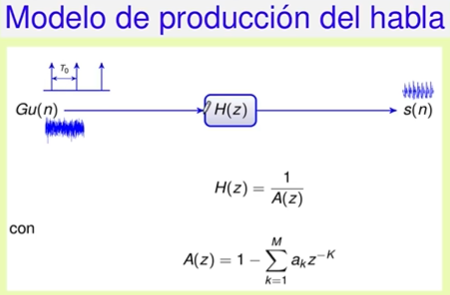

### Nota
>Gu(n) glotis
>
>sonido fricativo, las cuerda vocales s sepran
>
>H(z) es todo el tracto vocal hasat la boca incluso nariz.
>
>El obejtivo de ceptrum es obtener h(n) , separarlo

---
>T(z) transforma convoluciones en pmultiplicaciones, nosotros queremos transformarlo a sumas.
>
>surge el ceptrum.
>
>El log() no es un manifold, no tiene representacion unica!!!
>
>El logartimo tiene fase y eso haria que no pueda haber un manifold, nosotros tomamos el mdoulo del logartimo, perdemos info de la fase ... nose si es un manifold.






Suponemos que la señal de habla $s(n)$ esta representada por un sistema LTI ($H(z)$-todo el tracto vocal, desde la glotis hasta la boca o la naris) con un cierta entrada para los sonidos **vocalicos** representada por el tren de deltas o bien una señal ruidosa para los sonidos **fricativos**.

En la realida esas dos entradas no son constantes pues no son constates, el sistema y la entrada iran cambiando.
Pero para realizar un analisis se va a suponer que por una ventana de 25ms la forma del sistema se va a mantener asi.

Recordar que $$s(n) = Gu(n)*h(n) $$

Luego su respectiva tranformada $Z$ es
$$S(z) = G U(z) . H(z)$$

Pero el problema que tiene es que el efecto del filtro se presenta como una modulacion del espectro de entrada, esto dificulta el poder separarlos en el dominio $Z$.

Entonces se presenta otra transformación en donde las **convoluciones se van a transformar a sumas**, ademas de otras cosas.




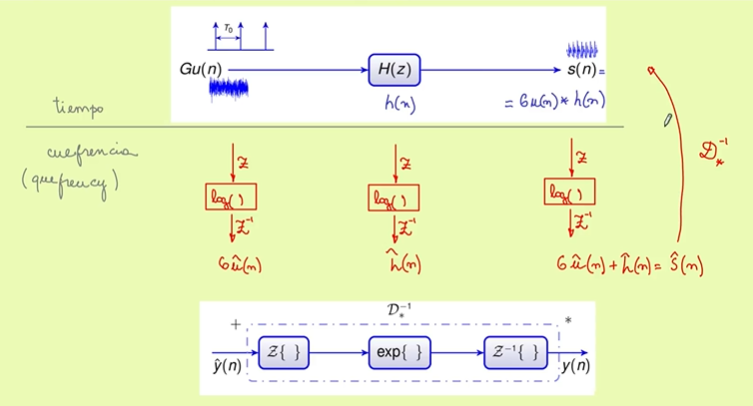

La nueva transformadacion que logra este objetivo $D$ es un sistema caracteristico que ademas es reversible $D^{-1}$

- Es una tranformada de fourier, un logaritmo y luego una ante-transformada.
- La "$n$" del dominio original representa tiempo, pero la "$n$" del dominio final ya no representa tiempo aunque si tiene las mismas unidades (fue transformada en el latente).
- La "$n$" final es la "$n$" del dominio *ceptrum* y se llama **cuefrencia**.
- Para volver del dominio **cuefrnecias** al dominio del **tiempo** tenemos $D^{-1}$.

Entonces cuales son las ventajas de usar ceptrum.

### Nota2

> - tomar la parrte de h(n) en ceptrum y volver a h(n) la llamamos liftering
>
> - cepsTRUM -> specTRUM
> - este ejemplo seria un pasa bajos.


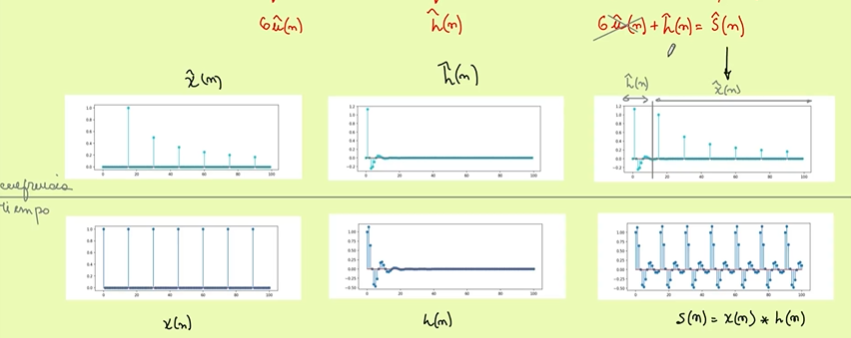

Si quiero caracterizar mi $h(n)$ "la caja" en el dominio del tiempo tendria que  convolucionar un tren de deltas con ver como se repite mi $h(n)$ pero es muy dificil separarlas para obtener $h(n)$.

En cambio si calculo el *ceptrum* de cada uno el resultado ya no es una convolucion sino que es una suma, y si el primer delta esta muy a derecha yo simplemente puede identificar rapidamente cual $h(n)$ y separarla muy facilmente para luego aplicar la inversa $D^{-1}$ y obtener la parte del sistema de produccion del habla $h(n)$ que es lo que distingue entre sonidos.


## ejercicio 1


### **1. Implementación del cepstrum real de una señal:**

**a)** Determine de forma analítica la expresión del **ceptrum complejo** de la siguiente señal:

$$
x(n) = x_1(n) * x_2(n) * x_3(n)
$$

donde:

$$
x_1(n) = a^n u(n), \quad
x_2(n) = \delta(n) + b\,\delta(n+1), \quad
x_3(n) = \delta(n) + \alpha \,\delta(n - N_p).
$$

Asuma que:

$$
a = 0{,}95, \quad b = 0{,}9, \quad \alpha = 0{,}7, \quad N_p = 15.
$$

---

**b)** Verifique la relación entre el **ceptrum complejo** calculado de forma teórica y el **ceptrum real** implementado con DFT.
Analice qué requisitos debe cumplir la señal para que el cepstrum obtenido mediante la DFT pueda emular al verdadero cepstrum.



formulas utiles
$$
X(z) = \sum_{-\infty}^{\infty} x(n)z^{-n}
$$

$$
\log(1+x) = \sum_{k=1}^{k=\infty} (-1)^{k+1}\frac{x^k}{k}
$$

$$
\log(1-x) = - \sum_{k=1}^{k=\infty} \frac{x^k}{k}
$$


In [ ]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import numpy.fft as ft

In [ ]:
def zplane(b,a,ax):
    from matplotlib import patches
    uc = patches.Circle((0,0), radius=1, fill=False, color='black', ls='dashed')
    ax.add_patches(uc)

    #obtengo polos y ceros.
    p = np.roots(a)
    z = np.roots(b)

    #Plot ceros y markers
    t1 = plt.plot(z.real, z.imag, 'go', ms=10)
    plt.step(t1, markersize =10.0, markeredgewidth=1.0, markercolor='k', markerfacecolor='g')

    #Plot polos y markers
    t2 = plt.plot(p.real, p.imag, 'rx', ms=10)
    plt.step(t2, markersize =10.0, markeredgewidth=1.0, markercolor='r', markerfacecolor='r')

    ax.spines['left'].set_position('zero')
    ax.spines['botton'].set_position('zero')
    ax.spines['right'].set_visible(False)

    r=1.5;plt.axis('scaled'); plt.axis([-r,-r,-r,-r])
    ticks = [-1,-0.5,0.5,1]; plt.xticks(ticks); plt.yticks(ticks)


### Nota 3

$x_2$ converge en todos lados pues no tiene ninguna sumatoria que devide, converge en todos lados.
peeero cuando aplicamos logartimoo la cosa cambia.

$u(-n-1)$ es un escalon que va al menos infinto CHAn.

en $x_1(n)$ cuando calculo el ceptrum el 1/n domina

en general: cuando hacemos $F^{-1}$ me devuelve la seññal par.


\begin{cases}
X(\Omega) \quad \xrightarrow{\quad F^{-1} \quad} \quad x(n)
\\
|X(\Omega)| \quad \xrightarrow{\quad F^{-1} \quad} \quad \dfrac{x(n) + x(-n)}{2}
\end{cases}

por tomar modulo!!!


**Calculo de ceptrum a)**

$$
x_1(n)= a^n u(n) \xrightarrow{D}  
\hat{x_1}(n) = \frac{a^n}{n}u(n-1)
\\
\\
x_2(n)=\delta(n) + b \delta(n+1) \xrightarrow{D}  
\hat{x_2}(n) = \frac{(-1/b)^n}{n}u(-n-1)
\\
\\
x_3(n)=\delta(n) + \alpha \delta(n - N_p) \xrightarrow{D}  
\hat{x_3}(n) =  -\sum_{r=1}^{\infty}   \frac{(-\alpha)^r}{r} \delta(n - rN_p)
$$


In [ ]:
# Genero y muestro las señales x1, x2, x3 y sus cepstra analíticas (según las fórmulas dadas),
# y calculo además el cepstrum "real" vía FFT (log|X(e^{jω})| -> IFFT).
# Ploteo todos los gráficos en figuras separadas (una sola figura por par señal/ceptrum).
# Requisitos: matplotlib, numpy. No se usan colores específicos (regla).


# Parámetros
a     = 0.95
b     = 0.9
alpha = 0.7
Np    = 15

# Rango de n a mostrar
n_min = -50
n_max =  50
n = np.arange(n_min, n_max+1)

# Construcción de x1, x2, x3 (definidas en todo el rango n)
x1 = np.where(n >= 0, a**n, 0.0)           # a^n u(n)

x2 = np.zeros_like(n, dtype=float)
x2[np.where(n == 0)]  = 1.0
x2[np.where(n == -1)] = b                  # delta[n+1] -> value at n=-1 is b

x3 = np.zeros_like(n, dtype=float)
x3[np.where(n == 0)]  = 1.0
x3[np.where(n == Np)] = alpha              # delta[n-Np] -> at n=NP is alpha


<StemContainer object of 3 artists>

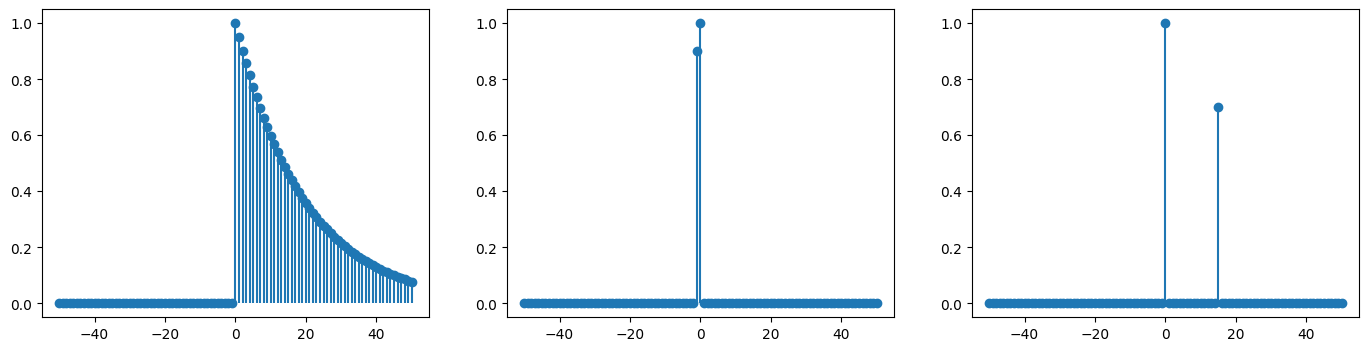

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(17,4))
axs[0].stem(n, x1, basefmt=" ")
axs[1].stem(n, x2, basefmt=" ")
axs[2].stem(n, x3, basefmt=" ")

In [ ]:
# Cepstrum analítico
# c1[n] = a^n / n  for n>=1
c1 = np.zeros_like(n, dtype=float)
idx_pos = n >= 1
c1[idx_pos] = a**(n[idx_pos]) / (n[idx_pos].astype(float))

# c2[n] = ((-1/b)^n)/n  for n <= -1
c2 = np.zeros_like(n, dtype=float)
idx_neg = n <= -1
# evitar división por cero; n[idx_neg] no contiene 0
c2[idx_neg] = ((-1.0/b)**(n[idx_neg].astype(float))) / (n[idx_neg].astype(float))

# c3[n] = - sum_{r>=1} ((-alpha)^r / r) delta(n - r*Np)
c3 = np.zeros_like(n, dtype=float)
# truncamos r hasta que alpha^r sea muy pequeño o hasta un máximo razonable
r_max = 40
for r in range(1, r_max+1):
    val = - ((-alpha)**r) / r
    pos = r * Np
    # ubicar índice n == pos
    if pos <= n_max:
        idx = np.where(n == pos)[0]
        if idx.size > 0:
            c3[idx[0]] += val

# Cepstrum total analítico (suma)
c_total_analytic = c1 + c2 + c3

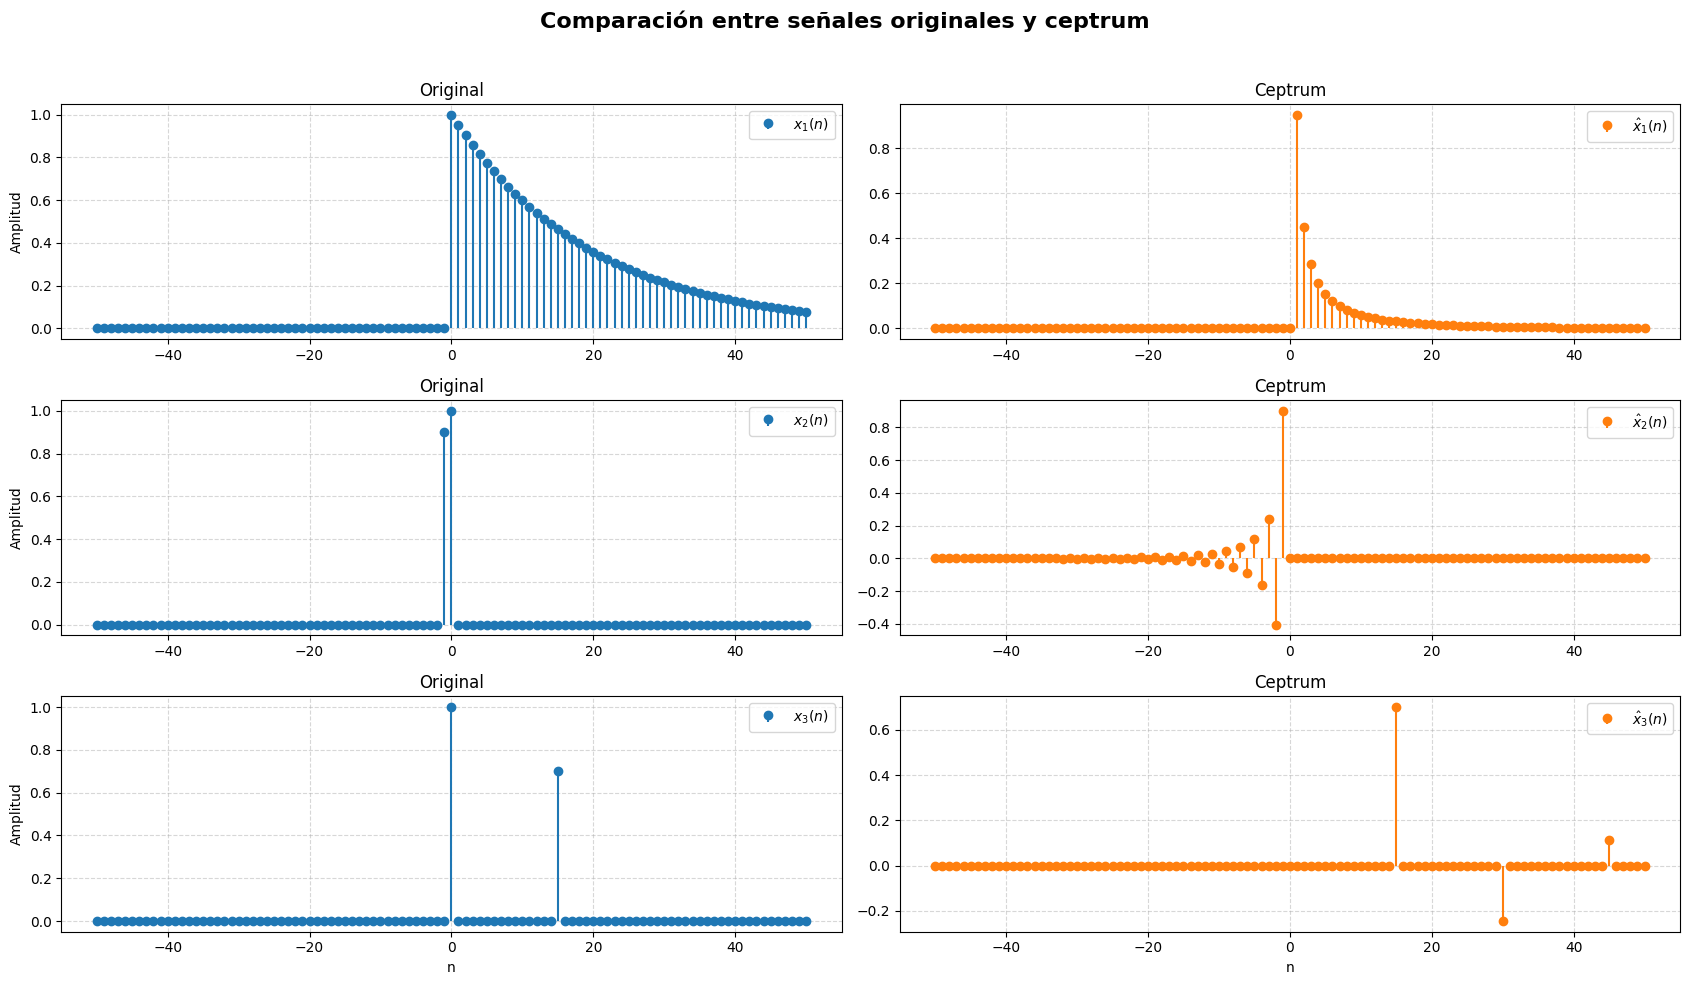

In [ ]:
# Crear la figura y los ejes
fig, axs = plt.subplots(3, 2, figsize=(17, 10))
fig.suptitle("Comparación entre señales originales y ceptrum", fontsize=16, fontweight='bold')

# Lista de señales y títulos
original_signals  = [x1, x2, x3]
estimated_signals = [c1, c2, c3]
titles = [r"$x_1(n)$ vs $\hat{x}_1(n)$", r"$x_2(n)$ vs $\hat{x}_2(n)$", r"$x_3(n)$ vs $\hat{x}_3(n)$"]

# Graficar cada par de señales
for i in range(3):
    # Señal original
    axs[i][0].stem(n, original_signals[i], basefmt=" ", linefmt='C0-', markerfmt='C0o', label=titles[i].split(" vs ")[0])
    axs[i][0].set_title("Original", fontsize=12)
    axs[i][0].set_ylabel("Amplitud")
    axs[i][0].grid(True, linestyle='--', alpha=0.5)
    axs[i][0].legend()

    # Señal estimada
    axs[i][1].stem(n, estimated_signals[i], basefmt=" ", linefmt='C1-', markerfmt='C1o', label=titles[i].split(" vs ")[1])
    axs[i][1].set_title("Ceptrum", fontsize=12)
    axs[i][1].grid(True, linestyle='--', alpha=0.5)
    axs[i][1].legend()

# Etiqueta del eje X solo en la última fila
for ax in axs[2]:
    ax.set_xlabel("n")

# Ajustar espaciado
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




**Cepstrum real (implementado con DFT):**

Se obtiene como:

$$
\hat{c}[n] = \text{IDFT}\left\{ \log |X[k]| \right\}.
$$

* Solo se utiliza el **módulo** del espectro, es decir, se descarta la fase.
* El resultado es **real y par** ($c[n] = c[-n]$).
* No reproduce exactamente el cepstrum complejo si la señal no cumple ciertas condiciones.

---

El cepstrum real **emula bien** al cepstrum complejo solo si la señal es **de fase mínima** (minimum-phase):

* Una señal **de fase mínima** es aquella cuyo espectro no tiene ceros fuera del círculo unitario en el plano Z.
* Bajo esta condición, el logaritmo complejo de $X(e^{j\omega})$ puede reconstruirse a partir de su módulo usando la relación de Hilbert.
* Entonces, $\log|X(e^{j\omega})|$ contiene toda la información necesaria, y el cepstrum real coincide con el complejo (al menos en la parte causal).



In [ ]:
N = len(n)
nfft = 1024 #2*N #1024

def get_naxis(L):
    if L % 2 == 1:
        x_comb_idx = np.arange(-(L//2), L//2 + 1)
    else:
        x_comb_idx = np.arange(-L//2, L//2)
    return x_comb_idx

def ceptrum(x, nfft, eps = 1e-12):
    """return 2*idft(log(|fft(x)|)), axis centrado en cero """
    X       = ft.fft(x, nfft)
    log_mag = np.log(np.abs(X) + eps)
    c       = ft.ifft(log_mag).real
    return 2*ft.fftshift(c), get_naxis(nfft)

x_comb = np.convolve(np.convolve(x1, x2), x3)
x_comb_idx = nc = np.linspace(-(len(x_comb)/2), len(x_comb)/2+1, len(x_comb))
idx_mask = (x_comb_idx>=-50) & (x_comb_idx<=51)
#----x(n)----
#x_comb = x_comb[:N]   # recortar para mantener longitud N
#----x_ceptrum(n)----
c_complejo = c1 + c2 + c3

#----ceptrum_real-fft----
c_real, idx_ceptrum = ceptrum(x_comb[idx_mask], nfft)

c1_real, idx_c1 = ceptrum(x1, nfft)
c2_real, idx_c2 = ceptrum(x2, nfft)
c3_real, idx_c3 = ceptrum(x3, nfft)

#El mismo indice para todos, osea de -pi a pi.
idx_mask_cep = (idx_ceptrum>=-50) & (idx_ceptrum<=51)
n_hat = idx_ceptrum[idx_mask_cep]



In [ ]:
(c2_real == c3_real).all()

np.False_

<StemContainer object of 3 artists>

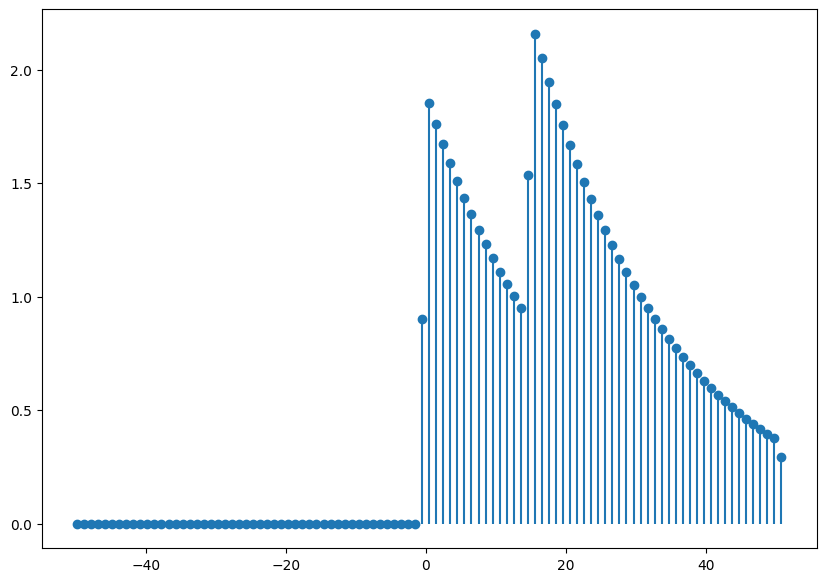

In [ ]:
plt.figure(figsize=(10,7))
plt.stem(x_comb_idx[idx_mask], x_comb[idx_mask], basefmt=" ", linefmt='C0-', markerfmt='C0o')
#plt.stem(idx_ceptrum[idx_mask_cep], c_real[idx_mask_cep], basefmt=" ", linefmt='C0-', markerfmt='C0o')

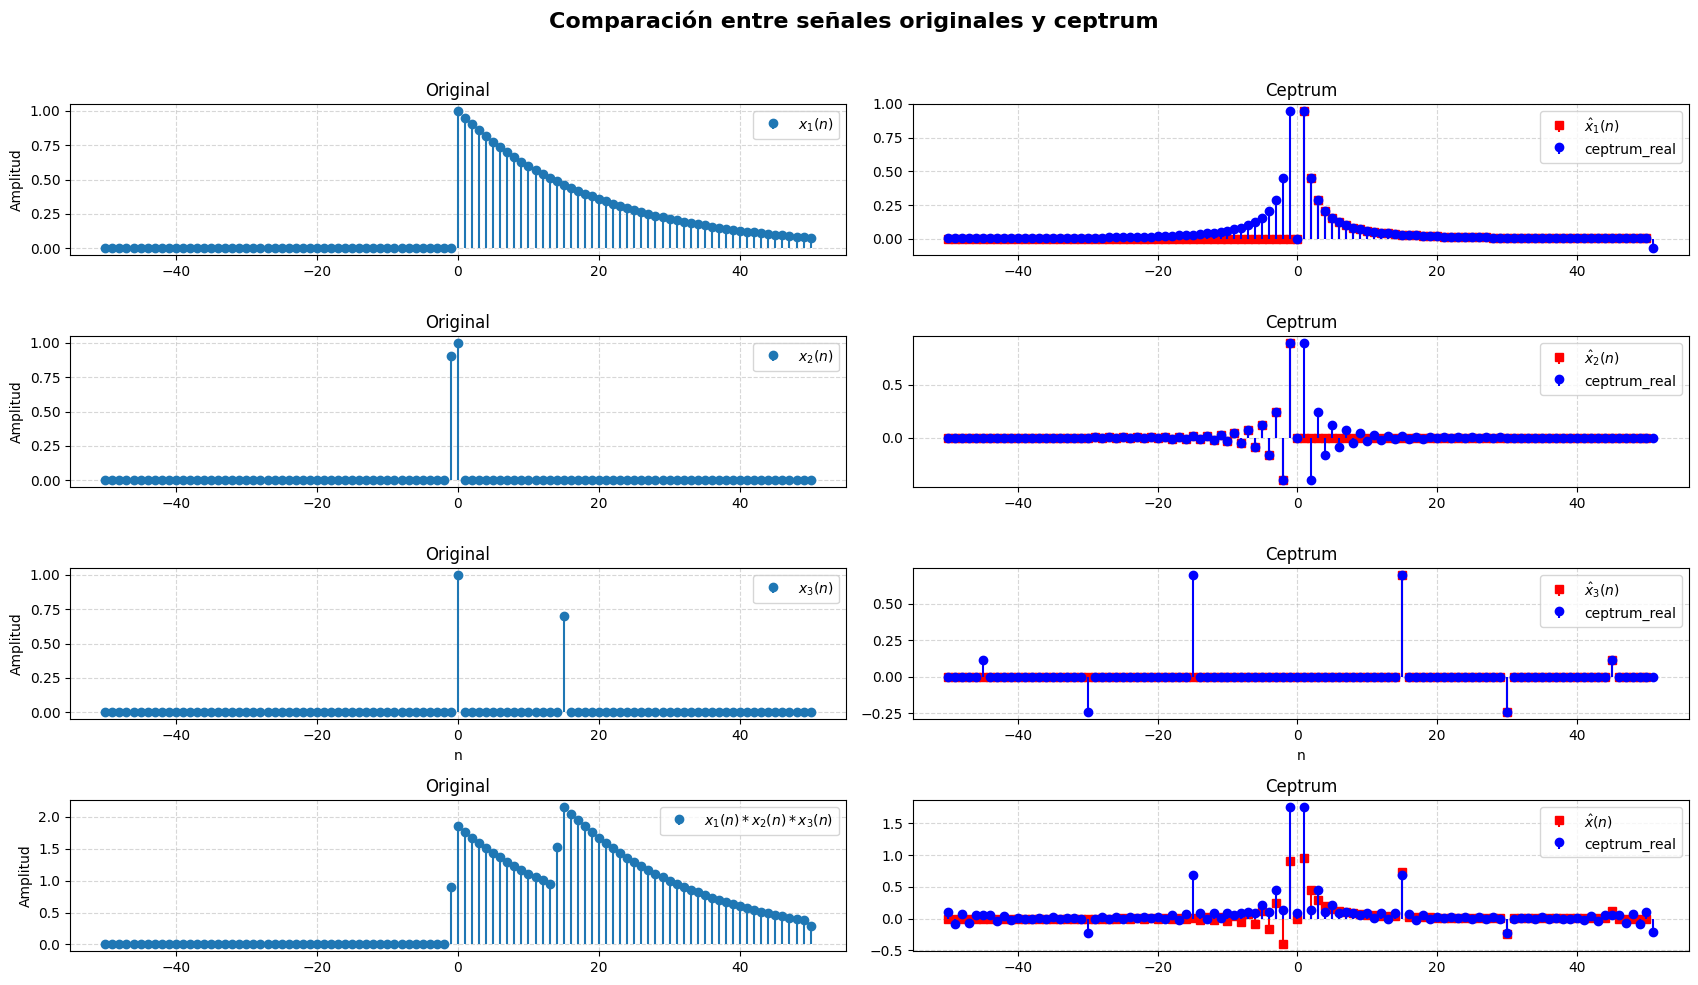

In [ ]:
# Crear la figura y los ejes
fig, axs = plt.subplots(4, 2, figsize=(17, 10))
fig.suptitle("Comparación entre señales originales y ceptrum", fontsize=16, fontweight='bold')

# Lista de señales y títulos
indices   = [n, n, n, n_hat]
n_ceptrum = [n_hat, n_hat, n_hat, n_hat]
original_signals  = [x1, x2, x3,  x_comb[idx_mask]]
estimated_signals = [c1, c2, c3, c_complejo]
liftering_signals = [c1_real[idx_mask_cep], c2_real[idx_mask_cep], c3_real[idx_mask_cep], c_real[idx_mask_cep]]
titles = [r"$x_1(n)$ vs $\hat{x}_1(n)$", r"$x_2(n)$ vs $\hat{x}_2(n)$", r"$x_3(n)$ vs $\hat{x}_3(n)$", r"$x_1(n)*x_2(n)*x_3(n)$ vs $\hat{x}(n)$"]

# Graficar cada par de señales
for i in range(4):
    # Señal original
    axs[i][0].stem(n, original_signals[i], basefmt=" ", linefmt='C0-', markerfmt='C0o', label=titles[i].split(" vs ")[0])
    axs[i][0].set_title("Original", fontsize=12)
    axs[i][0].set_ylabel("Amplitud")
    axs[i][0].grid(True, linestyle='--', alpha=0.5)
    axs[i][0].legend()

    # Señal estimada
    # 'r*' → estrella roja
    # 'rx' → cruz
    # 'rs' → cuadrado
    # 'rd' → diamante
    axs[i][1].stem(n, estimated_signals[i], basefmt=" ", linefmt='r-', markerfmt='rs', label=titles[i].split(" vs ")[1])
    # Señal real
    axs[i][1].stem(n_ceptrum[i], liftering_signals[i], basefmt=" ", linefmt='b-', markerfmt='bo', label="ceptrum_real")

    axs[i][1].set_title("Ceptrum", fontsize=12)
    axs[i][1].grid(True, linestyle='--', alpha=0.5)
    axs[i][1].legend()





# Etiqueta del eje X solo en la última fila
for ax in axs[2]:
    ax.set_xlabel("n")

# Ajustar espaciado
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


resumen, cuando queremos clacular el ceptrum con la computadora, solamente nos va a dar informacion util cuando estamos calculando señales cuyos ceptrum **son todos causales** osea todo cero del lado izquierdo(-n) por qu si llegamos a tener una señal de minima fase va a generar un ceptrum anti-causal y nos embarra nuestro ceptrum, se empiezan a superponer.


## Ejercicio 2

$$
H(z) = \frac{1}{1-\rho e^{j\theta}z^{-1}} \frac{1}{1-\rho e^{-j\theta}z^{-1}}
$$

ya tiene mas pinta de tracto vocal, es una especie de resonador, favorece ciertas frecuencias, para reforzar esas frecuencias, un especie de pasa bajo con un alto Q.



Liftering, utilización del Cepstrum para deconvolución.

Un sistema $H(z)$ con dos polos complejos conjugados ρe±jθ es excitado con un tren de deltas de duración
finita.

a) Calcule el cepstrum complejo analítico tanto de la excitación
$$
p_w(n) =∑_{r=0}^{L-1} β^r δ(n − r Np)
$$

con β = 0,9999, y Np = 15, como de la respuesta impulsiva del sistema h(n) con ρ = 0,8 y θ = π/4.

b) Compare gráficamente el cepstrum analítico con el obtenido mediante DFT. Qué precauciones deben
tomarse para que pueda utilizarse adecuadamente el cepstrum con DFT en este caso?

c) Obtenga a partir del cepstrum la envolvente del espectro utilizando Liftering. Determine la cantidad
de coeficientes apropiados y demás parámetros. Comparar con el liftering del cepstrum analítico

In [ ]:
import numpy as np
import scipy.signal as sig
from scipy import io
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import numpy.fft as ft


### calculo ceptrum de $p_w$

$$
H(z) = \frac{1}{1 -2cos(\theta) z^{-1} + \rho² z^{-2}}
$$


$$
p_w(n) =∑_{r=0}^{L-1} β^r δ(n − r Np)
$$

$\Longrightarrow$ **Aplico transformada Z y luego uso convergencia geometrica finita.**

$$
W(z)=\frac{1-\beta^{L} z^{-L N_p}}{1-\beta z^{-N_p}}.
$$

---

**1. Tomo el logaritmo:**

$$
\log W(z)=\log\!\big(1-\beta^{L} z^{-L N_p}\big)\;-\;\log\!\big(1-\beta z^{-N_p}\big).
$$

$\Longrightarrow$ (usar la serie de Taylor del logaritmo)

**Identidad útil** (válida si $|x|<1$):

$$
\log(1-x)=-\sum_{k=1}^{\infty}\frac{x^{k}}{k}.
$$

---

**2. Aplico la identidad a cada término:**

$$
\begin{aligned}
\log\!\big(1-\beta^{L} z^{-L N_p}\big)
&= -\sum_{k=1}^{\infty}\frac{(\beta^{L} z^{-L N_p})^{k}}{k}
= -\sum_{k=1}^{\infty}\frac{\beta^{L k}\; z^{-L k N_p}}{k},\\[6pt]
\log\!\big(1-\beta z^{-N_p}\big)
&= -\sum_{k=1}^{\infty}\frac{(\beta z^{-N_p})^{k}}{k}
= -\sum_{k=1}^{\infty}\frac{\beta^{k}\; z^{-k N_p}}{k}.
\end{aligned}
$$

$\Longrightarrow$ (restando ambos resultados)

$$
\boxed{\;
\log W(z)
= \sum_{k=1}^{\infty}\frac{\beta^{k}}{k}\; z^{-k N_p}
\;-\;
\sum_{k=1}^{\infty}\frac{\beta^{L k}}{k}\; z^{-L k N_p}
\;}.
$$

(esta es la forma en series en $z^{-1}$.)

---

**3. Paso al dominio del tiempo (inversa Z):**

Uso $\mathcal{Z}^{-1}\{z^{-n}\}=\delta[m-n]$ y la linealidad:

$$
\boxed{\;
\hat{p}_{w}(m) \stackrel{\mathcal{Z}^{-1}}{=}
\sum_{k=1}^{\infty}\frac{\beta^{k}}{k}\,\delta\big(m-kN_p\big)
\;-\;
\sum_{k=1}^{\infty}\frac{\beta^{L k}}{k}\,\delta\big(m-LkN_p\big)
\;}
$$

(esta es la expresión directa en función de deltas en los instantes $m=kN_p$.)





$$
\hat{p}(w) =  \sum_{r=1}^{\infty} \frac{\beta^r}{r} \delta(n-r N_p)
-
\sum_{q=1}^{\infty} \frac{(\beta^L)^q}{q} \delta(n-q (L N_p))
$$

### calculo ceptrum de h(n)


 Sistema con polos $\rho e^{\pm j\theta}$

$$
H(z)=\frac{1}{(1-\rho e^{j\theta} z^{-1})(1-\rho e^{-j\theta} z^{-1})}
=\frac{1}{1 - 2\rho\cos\theta\,z^{-1} + \rho^{2} z^{-2}}.
$$

Aplicando el logaritmo complejo:

$$
\log H(z) = -\log(1-\rho e^{j\theta} z^{-1}) - \log(1-\rho e^{-j\theta} z^{-1}).
$$

Usando la serie $\log(1-x) = -\sum_{k=1}^{\infty}\dfrac{x^k}{k}$ con $x=\rho e^{\pm j\theta} z^{-1}$:

$$
\begin{aligned}
\log H(z)
&= \sum_{k=1}^{\infty} \frac{(\rho e^{j\theta})^{k}}{k}\, z^{-k}
\;+\; \sum_{k=1}^{\infty} \frac{(\rho e^{-j\theta})^{k}}{k}\, z^{-k} \\[6pt]
&= \sum_{k=1}^{\infty} \frac{\rho^{k}}{k}\big(e^{j k\theta} + e^{-j k\theta}\big)\, z^{-k} \\[6pt]
&= \sum_{k=1}^{\infty} \frac{2\rho^{k}\cos(k\theta)}{k}\; z^{-k}.
\end{aligned}
$$

De ahí se leen los coeficientes del **ceptrum complejo** $c_h[n]$ (coeficientes de la expansión en potencias $z^{-n}$):

$$
\boxed{
c_{h}[n] \;=\;
\begin{cases}
\dfrac{2\,\rho^{n}\cos(n\theta)}{n}, & n=1,2,3,\dots\\[6pt]
0, & n\le 0
\end{cases}
}
$$

Con los valores numéricos $\rho=0.8,\ \theta=\pi/4$:

$$
c_h[n]=\frac{2\,(0.8)^{n}\cos\!\big(n\pi/4\big)}{n},\qquad n\ge1.
$$



$$
\boxed{\;
p_w(n) =∑_{r=0}^{L-1} β^r δ(n − r Np)
\\
\hat{p}_{w}(m) \stackrel{\mathcal{Z}^{-1}}{=}
\sum_{k=1}^{\infty}\frac{\beta^{k}}{k}\,\delta\big(m-kN_p\big)
\;-\;
\sum_{k=1}^{\infty}\frac{\beta^{L k}}{k}\,\delta\big(m-LkN_p\big)
\;}
$$


$$
\boxed{\;
H(z) = \frac{1}{1 -2cos(\theta) z^{-1} + \rho z^{-2}}
\\
\hat{h}[n]=\dfrac{2\,\rho^{n}\cos(n\theta)}{n},\qquad n\ge1.
\;}
$$


b) Compare gráficamente el cepstrum analítico con el obtenido mediante DFT. Qué precauciones deben tomarse para que pueda utilizarse adecuadamente el cepstrum con DFT en este caso?


In [ ]:
#Parametros:
#β = 0.9999
#Np = 15
#ρ = 0.8
#θ = np.pi/4

# ============================================================
# Configuración de parámetros (nada hardcodeado en funciones)
# ============================================================
params = {
    "β": 0.9999,      # factor de decaimiento en excitación
    "Np": 15,         # período en muestras
    "L": 200,         # longitud de la excitación
    "ρ": 0.8,         # módulo de polos del sistema
    "θ": np.pi/4,     # ángulo de polos
    "Nfft": 8192,     # tamaño de FFT (usar grande para evitar aliasing)
    "eps": 1e-12      # epsilon para evitar log(0)
}

In [ ]:
def zplane(b,a,ax):
    from matplotlib import patches
    uc = patches.Circle((0,0), radius=1, fill=False, color='black', ls='dashed')
    ax.add_patch(uc)

    #obtengo polos y ceros.
    p = np.roots(a)
    z = np.roots(b)

    #Plot ceros y markers
    t1 = plt.plot(z.real, z.imag, 'go', ms=10)
    plt.setp(t1, markersize =10.0, markeredgewidth=1.0, markeredgecolor='k', markerfacecolor='g')

    #Plot polos y markers
    t2 = plt.plot(p.real, p.imag, 'rx', ms=10)
    plt.setp(t2, markersize =12.0, markeredgewidth=3.0, markeredgecolor='r', markerfacecolor='r')

    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)

    r=1.5;plt.axis('scaled'); plt.axis([-r,r,-r,r])
    ticks = [-1,-0.5,0.5,1]; plt.xticks(ticks); plt.yticks(ticks)

In [ ]:
#b = numerador a=denominador
"""
                    -1              -M
        b[0] + b[1]z  + ... + b[M] z
Y(z) = -------------------------------- X(z)
                    -1              -N
        a[0] + a[1]z  + ... + a[N] z
"""

β   = 0.9999      # factor de decaimiento en excitación
Np  = 15         # período en muestras
L   = 200         # longitud de la excitación
ρ   = 0.8         # módulo de polos del sistema
θ   = np.pi/4     # ángulo de polos
Nfft= 8192     # tamaño de FFT (usar grande para evitar aliasing)


#H(z)
num = [1]
den = [1, -2*ρ*np.cos(θ), ρ*ρ]

n = np.arange(L*Np*20)

# δ(n)

delta = np.zeros(n.size); delta[0]=1.0
# h(n), dominio del tiempo.
h = sig.lfilter(    , den, delta)

fig, ax1 = plt.subplots(1,1, figsize=(12,5))
zplane(num, den, ax1)

fig, ax2 = plt.subplots(1,1, figsize=(12,5))

ax2.stem(n, h)
ax2.set(xlim=(0,100), xlabel='n', ylabel='h(n)-analitico')




SyntaxError: invalid syntax (ipython-input-4066420281.py, line 28)

In [ ]:
#b = numerador a=denominador
"""
                    -1              -M
        b[0] + b[1]z  + ... + b[M] z
Y(z) = -------------------------------- X(z)
                    -1              -N
        a[0] + a[1]z  + ... + a[N] z
"""

β   = 0.9999      # factor de decaimiento en excitación
Np  = 15         # período en muestras
L   = 200         # longitud de la excitación
ρ   = 0.8         # módulo de polos del sistema
θ   = np.pi/4     # ángulo de polos
Nfft= 8192     # tamaño de FFT (usar grande para evitar aliasing)


#H(z)
num = [1]
den = [1, -2*ρ*np.cos(θ), ρ*ρ]

n = np.arange(L*Np*20)

# δ(n)

delta = np.zeros(n.size); delta[0]=1.0
# h(n), dominio del tiempo.
h = sig.lfilter(num, den, delta)

fig, ax1 = plt.subplots(1,1, figsize=(12,5))
zplane(num, den, ax1)

fig, ax2 = plt.subplots(1,1, figsize=(12,5))

ax2.stem(n, h)
ax2.set(xlim=(0,100), xlabel='n', ylabel='h(n)-analitico')




In [ ]:
#fft(log(abs(fft(pn))))

# Practica-Markov

# Procesamiento del Habla — 66.46 y 86.53
# Práctica 6: Introducción a las Cadenas de Markov Ocultas (HMM)
# Semana 7

Esta práctica se basa en el material disponible en el sitio web de la *École Polytechnique Fédérale de Lausanne*, para el curso de Procesamiento y Reconocimiento del Habla.
Se utilizarán como datos el archivo `data.mat` y los programas disponibles en el campus, en su versión Matlab o Python.

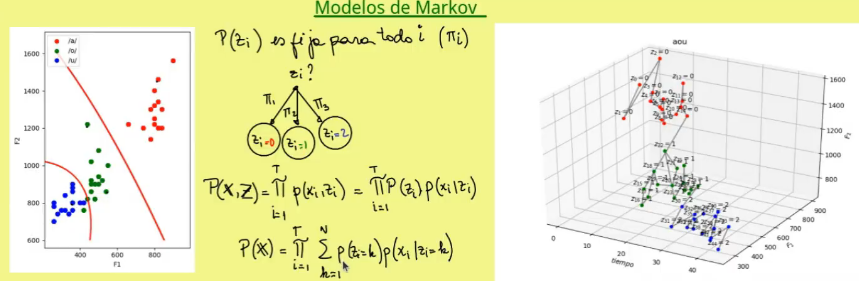

Ok, ahora tengamos en cuenta que venimos de p4roblemas de clasificacion en donde no teniamos en cuenta el tiempo (grafico izquierda) luego vemos que en realidad las mnuestras van aparecioendo conforme pasa el tiempo (grafico derecha) en el mismo vemos que se une desde $z_0$ en adelante y van apareciendo las muestras de cada formante.

Lo que dijo fue **AOU**

Ok, repasemos un poco y notemos que antes las distribuciones de los fonemas eran independientes, y por eso podria tener la productoria de las conjuntas y asi obtener la likelihood.

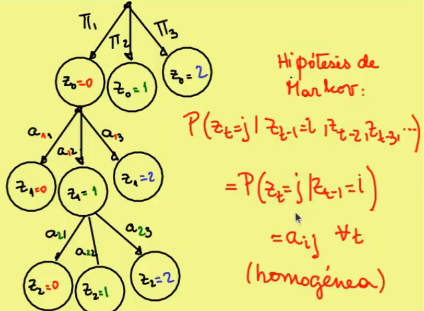

Ahora nosotros modelamos los estados con markov, hay una dependencia temporal con los estados anteriores pero solo de primer orden, osea que **mi estado actual solo depende del anterior** si hubo otros estados fuera de estado anterior no me interezan para esta hipotesis, la hipotesis de Markov.

Entonces, puedo arrancar con probabilidades inciiales $\Pi_0 = \{\pi_1, \pi_2, \pi_3\}$ y elegir un estado en base a esas probabilidades, en este caso elegio $z_0 = 0$ luego con otras probabiliades $\Pi_1 = \{a_{11}, a_{12}, a_{13} \}$ elijo el estado $z_1 = 1$ solo sabiendo que parto del estado anterior $z_0=0$.

Para el siguiente tiempo parte de $z_1 = 1$ con probabilidades $\Pi_2 = \{a_{21}, a_{22}, a_{23} \}$ y segun cual tenga mayor probabilidad elijo el estado.

> Notar las probabilidades $a_{ij}$ solo depende del estado anterior, estas seran estaticas, se reutilizaran constantemente.

Ok, ahora no vamos a modelar toda la secuencia de estados, seria engorroso y no daria mucha informacion.

Mejor se lo modela de la siguiente forma y se le asigna pesos segun la imagen a la derecha.

> Nota: si se le agrega el estado final se le conoce como delo de bakis (todos hacia delante)



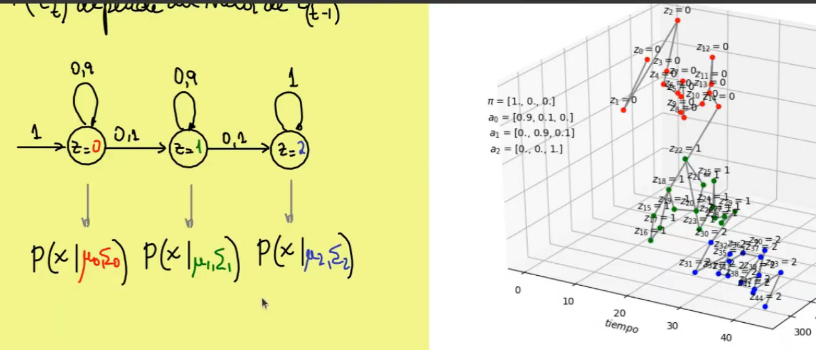

Recordemos un poco la Mezcla de gaussianas:

$$
\begin{align}
    p(\mathbf{X}, \mathbf{Z}) &= \prod\limits_{i=1}^{N}  p(x_i, z_i) =  \prod\limits_{i=1}^{N} p(z_i)p(x_i|z_i)
    \\
    &= p(x_1| z_1)p(x_2| z_2) \dots p(x_N| z_N)p(z_1)p(z_2)\dots p(z_N)
\end{align}
$$

Esta era la forma que teniamos cuando escribiamos mezcla de gaussianas en donde asumiamos conocida $z_i$ y el orden de los productos no nos afectan.

---
Ahora, es un poco distinto.



$$
\begin{align}
P(\mathbf{X}, \mathbf{Z}) &= p(x_1, z_1, x_2, z_2, x_3, z_3, \ldots)\\
&=
p(x_1, x_2, x_3, \ldots \mid z_1, z_2, z_3, \ldots) \; p(z_1, z_2, z_3, \ldots)\\
&=
p(x_1 \mid z_1) \; p(x_2 \mid z_2) \; \ldots \; p(z_1, z_2, z_3, \ldots) \quad \text{(2ª hipótesis de Markov)} \\
&=
p(x_1 \mid z_1) \; p(x_2 \mid z_2) \; \ldots \; p(z_T \mid z_{T-1}, z_{T-2}, \ldots) p(z_{T-1}, z_{T-2}, \ldots, z_1)\\
&=
p(x_1 \mid z_1) \; p(x_2 \mid z_2) \; \ldots \; p(z_T \mid z_{T-1})p(z_{T-1} \mid z_{T-2}) \ldots p(z_2|z_1)p(z_1) \quad \text{(1ª hipótesis de Markov)}
\end{align}
$$


Se usa la segunda hipotesis de markov que dice que $x_t$ solo depende de $z_t$ osea solo del estado actual

$$
\underbrace{
p(x_1 \mid z_1, z_2, \ldots, x_2, x_3, \ldots) \;
p(x_2 \mid x_3, \ldots, z_1, z_2, z_3, \ldots)
}_{\text{Segunda Hipótesis de Markov}}
\\
p(x_t \mid z_t) = p(x_t \mid z_t, z_{t+1}, z_{t+2}, \ldots, x_{t+1}, x_{t+2}, \ldots)
$$
Luegoi uno puede seguir condicionando para $x_2$ $x_3$ ...

y algo similar se hace para la primer hipootesis de markov, poero ahora con partiendo desde $z_T$.

$$
\boxed{P(\mathbf{X}, \mathbf{Z}) = p(z_1)p(x_1|z_1)∏\limits_{t=2}^{T}p(x_t|z_t)p(z_t|z_{t-1})}
$$

OK, entonces
$$
\begin{align}
p(z_1) &= \pi_i \\
p(x_1|z_1) &\sim 𝓝(μ, σ)\\
p(z_t|z_{t-1}) &= a_{ji}
\end{align}
$$

Escribamos la conjunta!!!

In [1]:
#markovData/data.mat

data_raw = "https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/data.mat"
markov = "https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/markov.py"

!wget -O data.mat "$data_raw"
!wget -O markov.py "$markov"

--2025-11-10 16:25:18--  https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/data.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13952 (14K) [application/octet-stream]
Saving to: ‘data.mat’

data.mat            100%[===================>]  13.62K  --.-KB/s    in 0.001s  

2025-11-10 16:25:18 (18.5 MB/s) - ‘data.mat’ saved [13952/13952]

--2025-11-10 16:25:18--  https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/markov.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12060 (12K) 

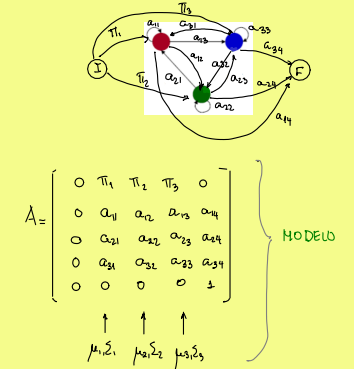

Lo de arriba se lo conoce como el modelo de markov.

En filas tenemos el estado anterior y en columnas el estado siguiente.

En este caso tiene 3 estados!, la primer fila corresponde a las probabilidades iniciales, luego la ultima columna corresponde al estado final, son las probabilidades de terminar.

La primer columna corresponde al estado inicial y es todo cero por que no se puede volver al estado inicial.

Esto es el modelo de Bakis!

Lo que hay que hacer es ver esos modelos y ver a cual pertenece! cual secuencia será!

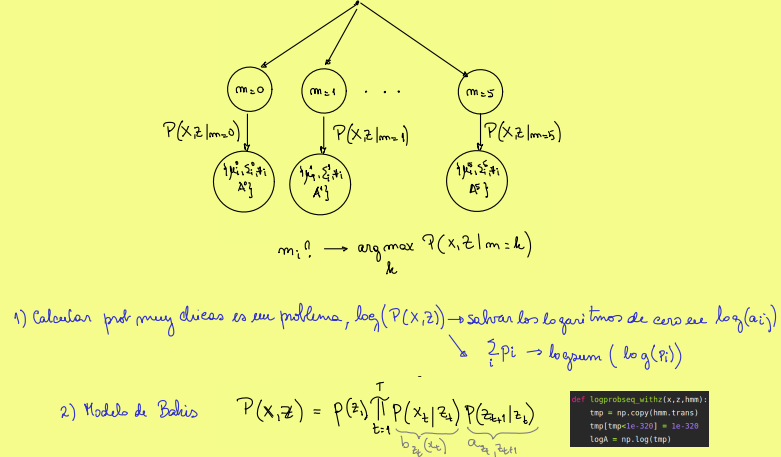

### 1. Descripción de un modelo de Markov con gaussianas

**a)** Usar la función `GenData` (en Python) o `inic_hmm.m` (en Matlab) para generar 6 modelos ocultos de Markov predeterminados: `model_i`, con $ i = 1, \ldots, 6 $.

Las secuencias ${X_1, Z_1}, \ldots, {X_6, Z_6}$ de observaciones ${X_k}$ y estados ${Z_k}$ fueron generadas por alguno de esos modelos (no necesariamente el índice indica cuál).

Usar $ P(X_k, Z_k \mid model_i) \ \forall k, i $, es decir, la probabilidad conjunta de la secuencia de observaciones y estados dado un modelo, para determinar **qué modelo** generó cada secuencia.


In [2]:

from markov import *
from matplotlib import animation
from matplotlib import patches
from matplotlib import gridspec
from mpl_toolkits import mplot3d


from threading import Event
from math import *
from random import randrange, uniform
from scipy import stats as sps
from scipy.io import loadmat


In [3]:
#hmm1, hmm2, hmm3, hmm4, hmm5, hmm6, hmm7 = GenData()

x = loadmat('data.mat')
X1, X2, X3, X4, X5, X6 = x['X1'], x['X2'], x['X3'], x['X4'], x['X5'], x['X6']
Z1 = x['ST1'].astype(int)[0]-1
Z2 = x['ST2'].astype(int)[0]-1
Z3 = x['ST3'].astype(int)[0]-1
Z4 = x['ST4'].astype(int)[0]-1
Z5 = x['ST5'].astype(int)[0]-1
Z6 = x['ST6'].astype(int)[0]-1

HMM = GenData() # un array de modelos
print(HMM)
HMM[3].__dict__

(<markov.hmm object at 0x7e08ef13ce30>, <markov.hmm object at 0x7e08ef1c7890>, <markov.hmm object at 0x7e08ef189760>, <markov.hmm object at 0x7e08e3ead100>, <markov.hmm object at 0x7e08e0906120>, <markov.hmm object at 0x7e08e09060f0>, <markov.hmm object at 0x7e08e09060c0>)


{'means': array([[ 730., 1090.],
        [ 270., 2290.],
        [ 440., 1020.]]),
 'vrs': array([[[ 1625.,  5300.],
         [ 5300., 53300.]],
 
        [[ 2525.,  1200.],
         [ 1200., 36125.]],
 
        [[ 8000.,  8400.],
         [ 8400., 18500.]]]),
 'trans': array([[0.  , 1.  , 0.  , 0.  , 0.  ],
        [0.  , 0.95, 0.05, 0.  , 0.  ],
        [0.  , 0.  , 0.95, 0.05, 0.  ],
        [0.  , 0.  , 0.  , 0.95, 0.05],
        [0.  , 0.  , 0.  , 0.  , 1.  ]]),
 'dim': 2,
 'numStates': 5,
 'devs': array([[[ 35.,  20.],
         [ 20., 230.]],
 
        [[ 50.,   5.],
         [  5., 190.]],
 
        [[ 80.,  40.],
         [ 40., 130.]]])}

In [4]:
print(HMM[0].trans)
print(HMM[1].trans)
print(HMM[2].trans)

[[0.  1.  0.  0.  0. ]
 [0.  0.4 0.3 0.3 0. ]
 [0.  0.3 0.4 0.3 0. ]
 [0.  0.3 0.3 0.3 0.1]
 [0.  0.  0.  0.  1. ]]
[[0.    1.    0.    0.    0.   ]
 [0.    0.95  0.025 0.025 0.   ]
 [0.    0.025 0.95  0.025 0.   ]
 [0.    0.02  0.02  0.95  0.01 ]
 [0.    0.    0.    0.    1.   ]]
[[0.  1.  0.  0.  0. ]
 [0.  0.5 0.5 0.  0. ]
 [0.  0.  0.5 0.5 0. ]
 [0.  0.  0.  0.5 0.5]
 [0.  0.  0.  0.  1. ]]


Funciones para graficar!

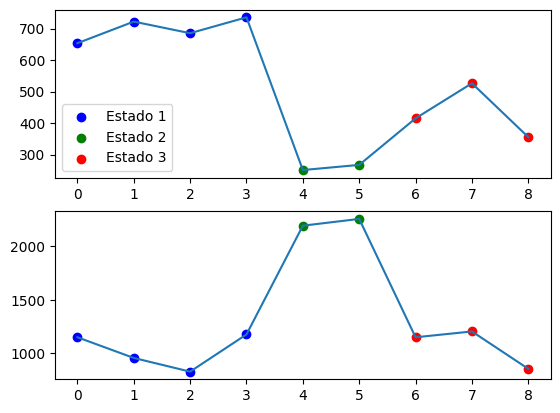

In [5]:
#op1: protseq en esjes separados cada componenete.
ax1, ax2 = plotseq(HMM[0], Z2, X2)
#Notar que x tiene dos nunmeros, es coordenada pero se lo represanta en 1D por eso
# se usa dos graficos.

Text(0.5, 1.0, 'HMM[3], secuencia X2, Z2')

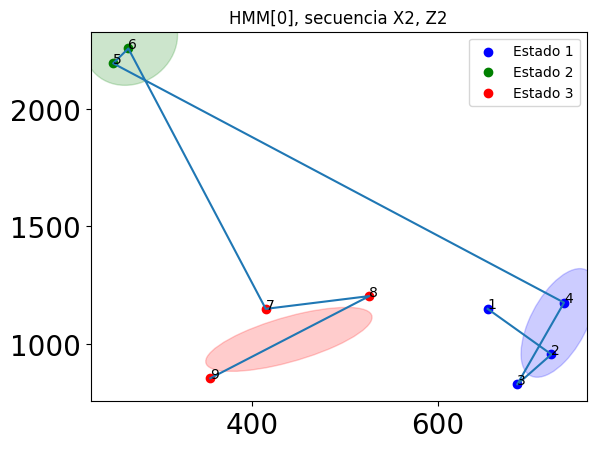

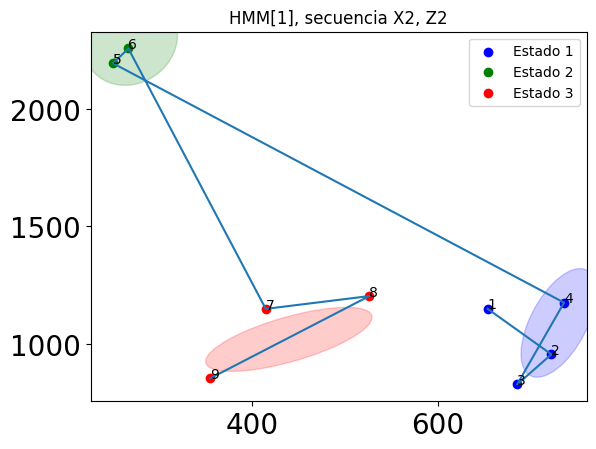

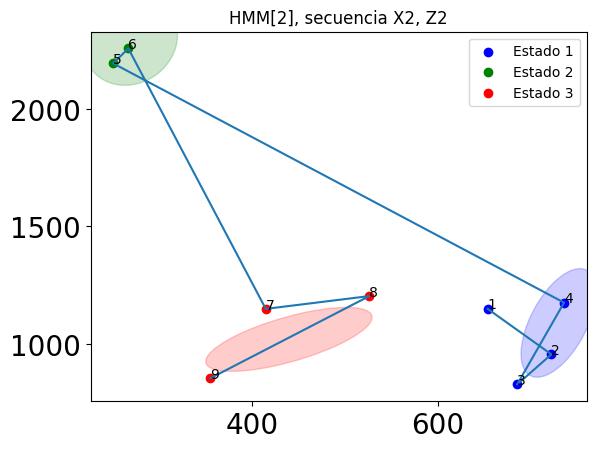

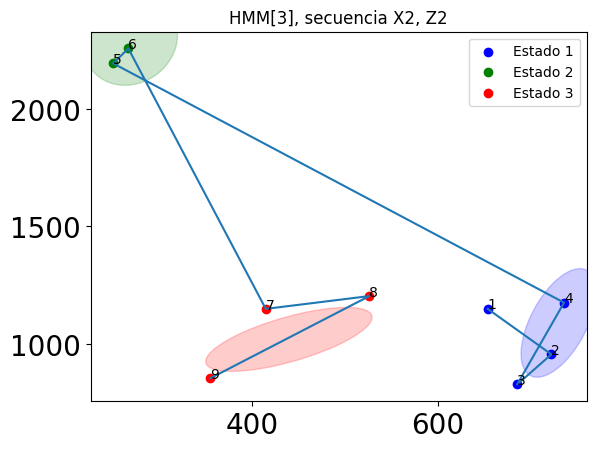

In [6]:
ax = plotseq2(HMM[0], Z2, X2, gauss=True)
ax.set_title('HMM[0], secuencia X2, Z2')

ax = plotseq2(HMM[1], Z2, X2, gauss=True)
ax.set_title('HMM[1], secuencia X2, Z2')

ax = plotseq2(HMM[2], Z2, X2, gauss=True)
ax.set_title('HMM[2], secuencia X2, Z2')

ax = plotseq2(HMM[3], Z2, X2, gauss=True)
ax.set_title('HMM[3], secuencia X2, Z2')

Text(0.5, 1.0, 'HMM[5], secuencia X2, Z2')

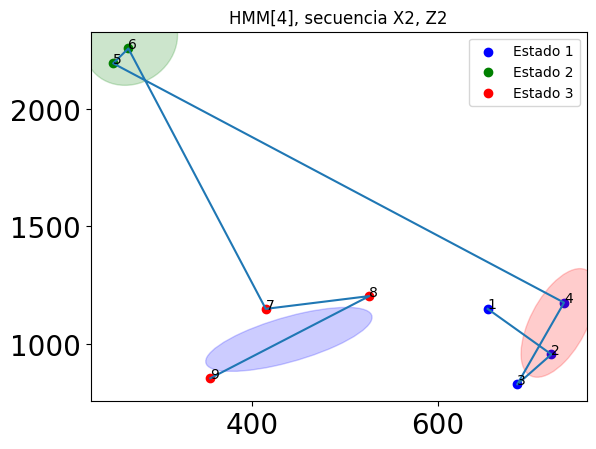

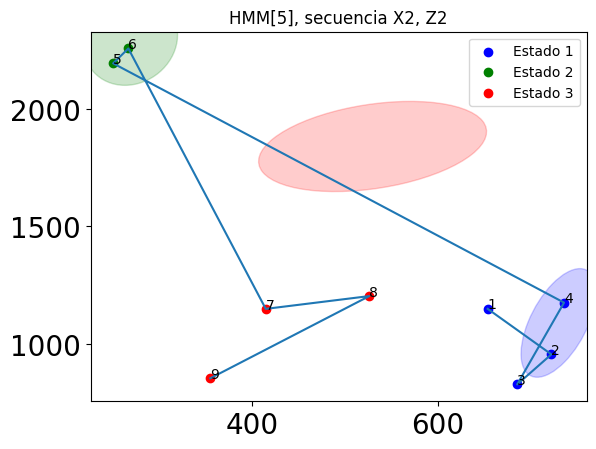

In [7]:

ax = plotseq2(HMM[4], Z2, X2, gauss=True)
ax.set_title('HMM[4], secuencia X2, Z2')

ax = plotseq2(HMM[5], Z2, X2, gauss=True)
ax.set_title('HMM[5], secuencia X2, Z2')

La opccion que se pide es la opccion cero.

Osea calcular la probabilidad de la secuencia conociendo los z.

Partimos de o siguiente.

$$
\boxed{P(\mathbf{X}, \mathbf{Z}) = p(z_1)p(x_1|z_1)∏\limits_{t=2}^{T}p(x_t|z_t)p(z_t|z_{t-1})}
$$

y considerando el modelo de Bakis.

$$
\boxed{P(\mathbf{X}, \mathbf{Z}) = p(z_1)∏\limits_{t=1}^{T}\underbrace{p(x_t|z_t)}_{b_{z_t}(x_t)}  \underbrace{p(z_{t+1}|z_{t})}_{a_{z_t, z_{t+1}}}}
$$

Para evitar underflow de los parametros vamos a usar logaritmo (las productorias de los $a_{ij}<1$ van a ser cada vez mas chicos)

$$
\boxed{
\log P(\mathbf{X}, \mathbf{Z}) = \log p(z_1) + \sum_{t=1}^{T} \log p(x_t | z_t) + \sum_{t=1}^{T-1} \log p(z_{t+1} | z_t)
}
$$

In [8]:
def logprobseq_withz(x,z,hmm):
    tmp = np.copy(hmm.trans); tmp[tmp<1e-320] = 1e-320
    logA = np.log(tmp)

    logp = logA[0, z[1]] #priori.
    T = len(z)

    #X:    1, ..., T-1
    #Z: 0, 1, ..., T-1, T

    for t in range(1, T-1):
        # N(x[t], mu[t], var[t])
        logp += sps.multivariate_normal.logpdf(x[t-1], hmm.means[z[t]-1], hmm.vrs[z[t]-1]) #z_t = {1,2,3}-> z_t-1: {0,1,2}
        # a[t,t+1]
        logp += logA[z[t], z[t+1]]

    return logp



for idx, (x, z) in enumerate(zip([X1,X2,X3,X4,X5,X6], [Z1,Z2,Z3,Z4,Z5,Z6])):
    logp= logprobseq_withz(x, z, HMM[idx])
    print(f"model_{idx+1}, p ={np.exp(logp)}, plog: {logp}")


model_1, p =1.0940366828701227e-243, plog: -559.4383033631556
model_2, p =9.513889452498292e-52, plog: -117.48167205720351
model_3, p =0.0, plog: -1481.6402261140329
model_4, p =0.0, plog: -820.3114975419973
model_5, p =0.0, plog: -1055.6183720342328
model_6, p =0.0, plog: -4540.221819391847


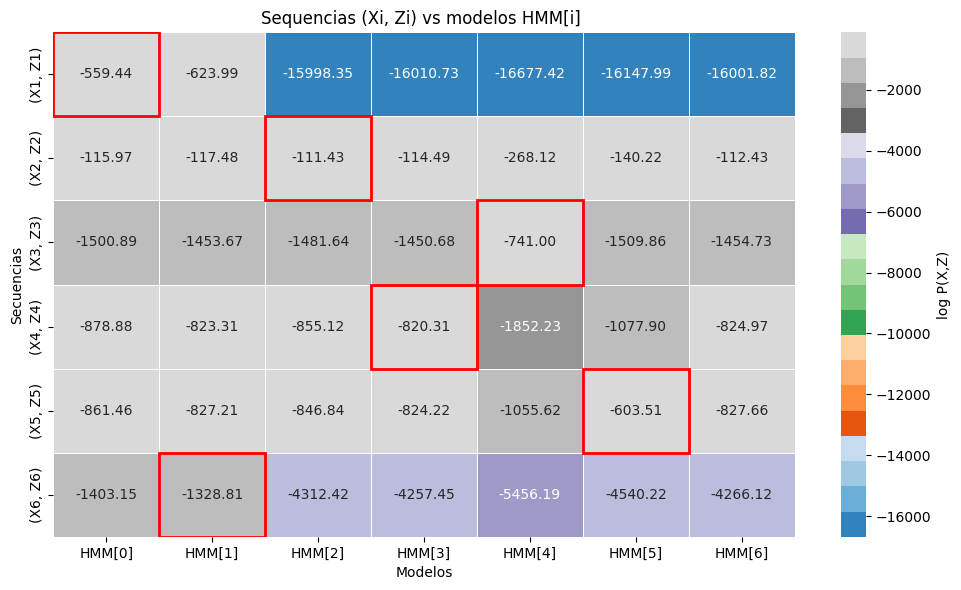

In [9]:
import pandas as pd
import seaborn as sns
sequences     = [(X1, Z1), (X2, Z2), (X3, Z3), (X4, Z4), (X5, Z5), (X6, Z6)]
num_sequences = len(sequences)
num_models    = len(HMM)


log_probs_matrix = np.zeros((num_sequences, num_models))


for i, (x, z) in enumerate(sequences):
    for j in range(num_models):
        logp = logprobseq_withz(x, z, HMM[j])
        log_probs_matrix[i, j] = logp


confusion_df = pd.DataFrame(log_probs_matrix,
                            index=[f"(X{i+1}, Z{i+1})" for i in range(num_sequences)],
                            columns=[f"HMM[{j}]" for j in range(num_models)])
max_coords = np.argmax(log_probs_matrix, axis=1)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_df, annot=True, fmt=".2f", cmap="tab20c", linewidth=.5, cbar_kws={'label': 'log P(X,Z)'})

# Dibujar un recuadro alrededor de la celda seleccionada
for i, j in enumerate(max_coords):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=2))

plt.title("Sequencias (Xi, Zi) vs modelos HMM[i] ")
plt.xlabel("Modelos")
plt.ylabel("Secuencias")
plt.tight_layout()



Text(0.5, 1.0, 'HMM[5], secuencia X5, Z5')

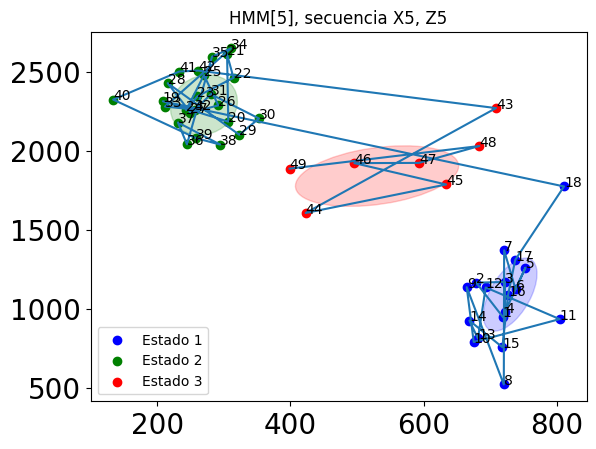

In [10]:

ax = plotseq2(HMM[5], Z5, X5, gauss=True)
ax.set_title('HMM[5], secuencia X5, Z5')

**b)** Usar la función `logfwd`, que calcula la **recursión hacia adelante (α-recursión)**, para obtener
$ P(X_k \mid model_i) $: la probabilidad de las observaciones dadas todas las posibles secuencias de estados, para cada modelo.

Analizar qué relación existe entre esta probabilidad y la calculada en el ítem anterior.

Cuál sería el metodo que usaríamos si hacemos una extrapolacón directa de lo que hicimos en mezclas de gaus?

Marginalizar los $Z$ -> *Sumar sobre todos los $z_t$ posibles individualmente*

**si iid**:
 $$
 P(X,Z) = ∏_\limits{i=1}^{T}p(x_i,z_i) → p(X) = ∏_\limits{i=1}^{T} ∑_\limits{k=1}^{K}p(x_i,z_i=k) = ∏_\limits{i=1}^{T} ∑_\limits{k=1}^{K} p(z_i=k) p(x_i|z_i=k)
 $$


Esto dice que si no conozco las etiquetas en cada tiempo sumo todas las etiquetas posibles!

**si HMM**
$$
p(x_1^T, z_1^{T+1}) = ∏_\limits{t=1}^{T} p(x_t|z_t) [ p(z_1])∏_\limits{t=1}^{T}p(z_{t+1}|z_t) ]
$$


Ok, para entender esto partamos de lo que haciamos en el ejercicio anterior.

conociendo las etiquetas uno puede pasar del estado inicial al final.

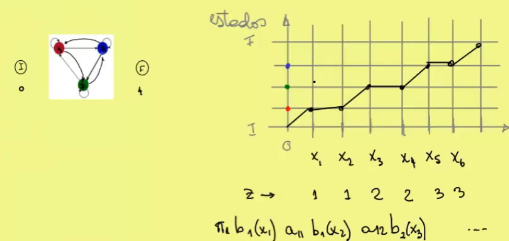

Ahora el problema es que si no conozco las etiquetas vos a tener que marginalizar, osea sumar en todos los posibles estados sobre $x_i$.


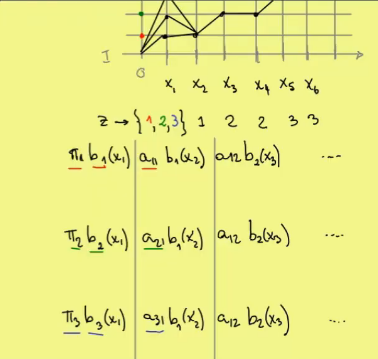

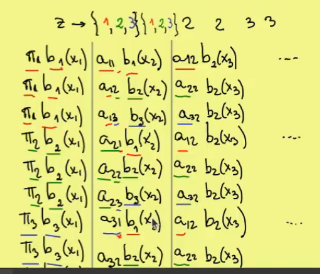

Notar que si bien cambia la primer columna osea tener que considerar todos los posibles estados iniciales tambien cambia lo que tengo que poner en el siguiente estado **por que depende del estado anterior** ya **no es iid**

y si aun asi quiero hacerlo para el siguiente estado se complica aun mas por que no son independientes! la suma se hace muy grande.

entonces, **sumar no va a ser posible por que tengo muchas secuencias que completar**

La solucion es notar que para el estado $x_3$ no vamos a necesitart la informacion del estado $x_1$ y entonces voy a poder ir marginalizando recursivamente!!

De esta forma no voy a necesitar las etiquetas.

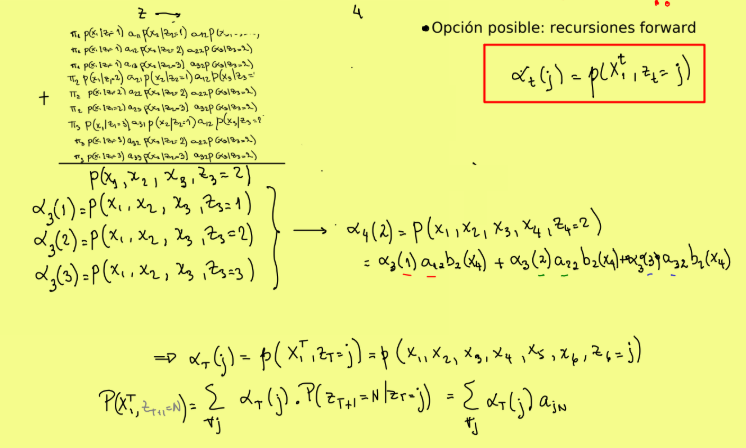

Entonces, esto se lo llama recursion $α$ que calcula la probabilidad de la secuencia hasta el estado $t$ y del estado t igual a j.

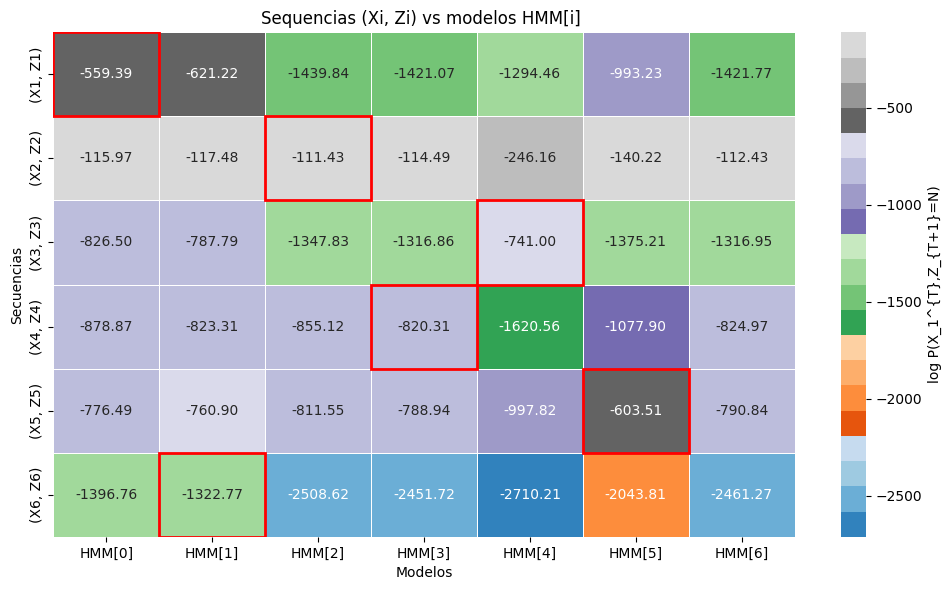

In [11]:

log_probs_matrix = np.zeros((num_sequences, num_models))


for i, (x, z) in enumerate(sequences):
    for j in range(num_models):
        log_prob, log_alpha = logfw(x, HMM[j])

        log_probs_matrix[i, j] = log_prob


confusion_df = pd.DataFrame(log_probs_matrix,
                            index=[f"(X{i+1}, Z{i+1})" for i in range(num_sequences)],
                            columns=[f"HMM[{j}]" for j in range(num_models)])
max_coords = np.argmax(log_probs_matrix, axis=1)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_df, annot=True, fmt=".2f", cmap="tab20c", linewidth=.5, cbar_kws={'label': 'log P(X_1^{T},Z_{T+1}=N)'})

# Dibujar un recuadro alrededor de la celda seleccionada
for i, j in enumerate(max_coords):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=2))

plt.title("Sequencias (Xi, Zi) vs modelos HMM[i] ")
plt.xlabel("Modelos")
plt.ylabel("Secuencias")
plt.tight_layout()


OK, ahira vamos a explicar por que la necesidad de la recursion $ᵝ$

Que pasaria si quisieramos toda la secuencia y que algún estado intermedio sea igual a $j$

Partimos de la recursion anterior.

$$
\begin{align}
P(x_1^T, z_t = j)
&= P(x_1^t, x_{t+1}^T, z_t = j)\\
&= P(x_1^t|  x_{t+1}^T,  z_t = j) P(x_{t+1}^T, z_t = j)
\quad \text{no depende de } x_{t+1}\\
&= P(x_1^t|,  z_t = j) P(x_{t+1}^T, z_t = j)
\quad \text{puedo condicionar en }z_t\\
&= P(x_1^t|,  z_t = j) P(x_{t+1}^T| z_t = j) P( z_t = j)
\quad \text{reagrupo primero y ultimo}\\
&= P(x_1^t|,  z_t = j)P( z_t = j)\ P(x_{t+1}^T| z_t = j)\\
&= \underbrace{P(x_1^t, z_t = j)}_{\alpha_t(j)
\quad} , \underbrace{P(x_{t+1}^T | z_t = j)}_{\beta_t(j)}\\
&= \alpha_t(j).\beta_t(j)
\end{align}
$$

Vemos que se puede calcular a partir de la recursion alpha en algun j con una recursion beta que ahora vemos como calcular y esto es importante por que si puedo tener mio conjunta para algun j pudo sumar en todo j para así marginalizar y obtener:

---

**Probabilidad total de la secuencia(desde $x_1$ hasta $x_T$):**

$$
P(x_1^T) = \sum_j P(x_1^T, z_t = j)
= \sum_j \alpha_t(j) , \beta_t(j)
\quad \text{para cualquier } t
$$


Con esto ya puedo calcular la responsabilidad $γ$ que me va a permitir escribir un **EM** para markov! se llama **Baun-welch**

---

**Probabilidad posterior de un estado dado las observaciones (**γ** o responsabilidad):**

$$
\gamma_t(j) = P(z_t = j \mid x_1^T)
= \frac{P(x_1^T, z_t = j)}{P(x_1^T)}
= \frac{\alpha_t(j), \beta_t(j)}{\sum_j \alpha_t(j), \beta_t(j)}
$$

> Nota: ahora con el alpha y beta yo ya puedo escribir la responsabilidad en cada estado.
---

### Probabilidad conjunta de dos estados consecutivos (**ξ**):

$$
\xi_t(j,h) = P(z_t = j, z_{t+1} = h \mid X^T)
= \frac{\alpha_t(j), a_{jh}, b_h(x_{t+1}), \beta_{t+1}(h)}
{\sum_j \alpha_t(j), \beta_t(j)}
$$


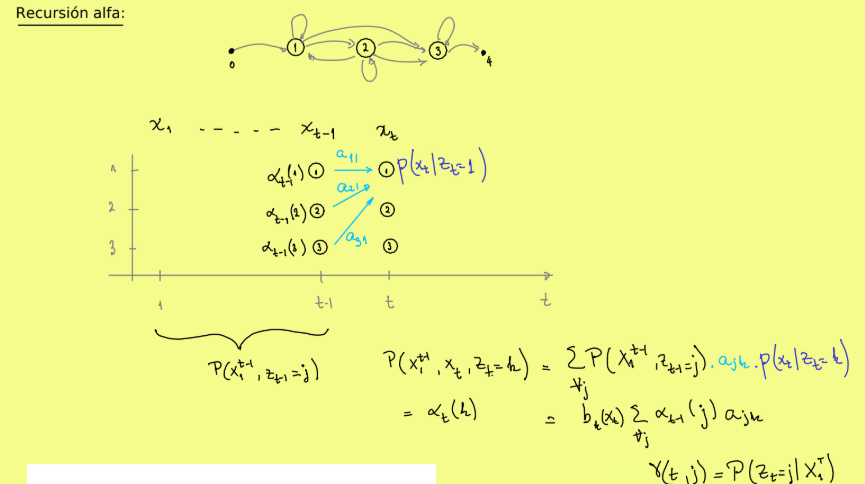

esta es la formula que está implementada en lofFW()

Ahora la recursión beta, partimos diciendo que conocemos desde t+1 a T.

Luego calculamos lo que haga falta

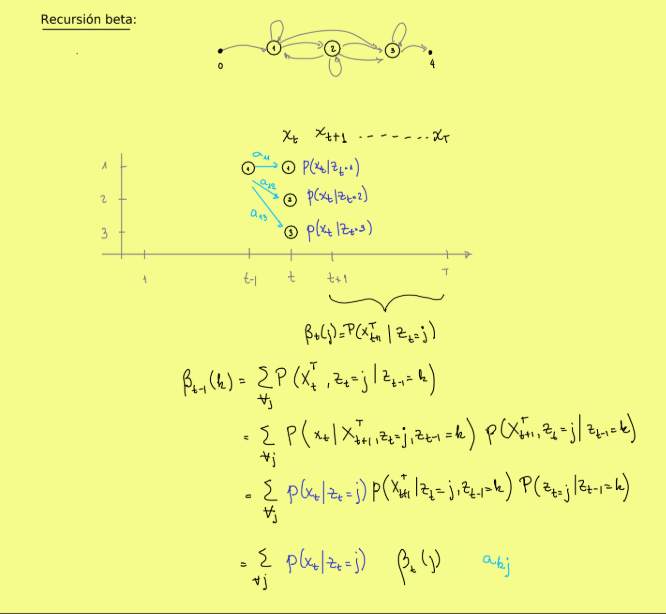

### 2. Entrenamiento de parámetros de Cadenas de Markov Ocultas (Algoritmo de Baum–Welch)

**a)** En este apartado se realizará un entrenamiento **Baum–Welch** de los parámetros de una cadena de Markov oculta.

Usando el modelo `hmm4`, generar una secuencia de observaciones $ X $ que servirá como **datos de entrenamiento**.

La función `logfwd` utilizada anteriormente calcula (el logaritmo de) las probabilidades $ \alpha_k(t) $ para todo $k$ y $t$.

Generar un programa que calcule las matrices con los valores de
$$
\alpha_k(t), \ \beta_k(t), \ \gamma_k(t), \ \xi_{jk}(t)
$$
para toda la secuencia de observaciones, usando el programa anterior como base para calcular las demás probabilidades.

Prestar especial atención a cómo se manejan las **sumas de probabilidades** en ese programa.



**b)** Tomando como base el programa de estimación EM implementado en la práctica 6, realizar las **modificaciones necesarias** para estimar los parámetros del modelo `hmm4`, utilizando las matrices calculadas en el punto anterior.

Comparar los resultados obtenidos con los **parámetros verdaderos**.

Realizar **dos entrenamientos**:

1. Inicializando todas las medias y varianzas con el mismo valor (igual a las medias y varianzas globales).
2. Inicializando con **segmentación temporal uniforme**.



**c)** Repetir el entrenamiento usando una secuencia generada por `hmm6`, con ambas inicializaciones.


La formula que ya tenemos hecha es logfw recursion forward.

La que hay que hacer es la backward

Ojo que son muy poarecidas y engañan


La primera la sumatoria es en j  y en es en j por eso puedo sacar $b$ afuera luego en la segunda la sumatoria es de j y el b es de j entonces no lo puedo sacar

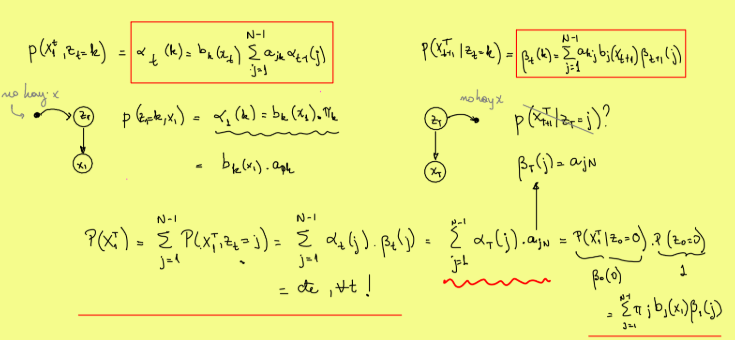


```python

def logfw(X,hmm):
    """
        Función para implementar la recursión alpha.
    """
    
    T = X.shape[0] # Cantidad de mediciones
    N = hmm.numStates - 2 # Cantidad de estados sin contar el final y el inicial
#     zero = 1e-100 # Valor mínimo para evitar división por cero

    tmp = np.copy(hmm.trans)
    tmp[tmp<1e-320] = 1e-320
    logA = np.log(tmp)

    # Evaluación del logaritmo de la normal de cada estado y cada x_t
#     log_b = logpdfnorm(hmm.means,hmm.vrs,X)
    
    log_b = -np.ones((N,T))*np.log(2*np.pi)
    for k in range(N):
        log_b[k,:] -= 0.5 * np.log(np.linalg.det(hmm.vrs[k]))
        x_unbiased = X - hmm.means[k,np.newaxis]
        inv_sig =  np.linalg.inv(hmm.vrs[k])
        log_b[k,:] -= 0.5 * np.einsum('ij,ij->i',x_unbiased @ inv_sig, x_unbiased).T
            
    # Matriz de transición para la recursión
#     log_trans = hmm.trans.T[1:-1,1:-1].copy()
#     log_trans[log_trans<zero] = zero
#     np.log(log_trans, out=log_trans)
    
    # Inicialización del log_alpha
#     log_alpha = np.zeros((N,T))
    log_alpha = np.empty((N,T))
    log_alpha[:,0] = log_b[:,0] + logA[0,1:-1].T
#     log_a0 = hmm.trans[0,1:-1].copy()
#     log_a0[log_a0<zero] = zero
#     np.log(log_a0, out=log_a0)
#     log_alpha[:,0] = log_b[0,:] + log_a0
    
    # Recursión alfa
    for t in range(1,T):
        for k in range(N):
#             log_alpha[k,t] = log_b[t,k] + logsumexp(log_trans[:,k]+log_alpha[:,t-1])
                log_alpha[k,t] = log_b[k,t] + logsumexp(logA[1:-1,k+1] + log_alpha[:,t-1])
    # Cálculo de la probabilidad
#     log_af = hmm.trans[1:-1,-1].copy()
#     log_af[log_af<zero] = zero
#     np.log(log_af, out=log_af)
    log_prob = logsumexp(logA[1:-1,-1]+log_alpha[:,-1])

    
    return log_prob, log_alpha
```

In [12]:
from scipy.special import logsumexp
def logbw(X, hmm):
    """
    Calcula las probabilidades backward (β) en el dominio logarítmico.
    Retorna log_prob (P(x_{t+1}^{N-1}|z_t=k)) y log_beta (matriz N×T).
    """
    T = X.shape[0]                 # cantidad de observaciones
    N = hmm.numStates - 2          # sin contar inicio y fin

    tmp = np.copy(hmm.trans)
    tmp[tmp < 1e-320] = 1e-320
    log_A = np.log(tmp)

    # log_b[k,t] = log p(x_t | z_t = k) / j={k=1..k=N}, X={x1...xT}
    log_b = -np.ones((N,T))*np.log(2*np.pi)
    for k in range(N):#para todo T->:
        log_b[k,:] -= 0.5 * np.log(np.linalg.det(hmm.vrs[k]))
        x_unbiased = X - hmm.means[k,np.newaxis]
        inv_sig =  np.linalg.inv(hmm.vrs[k])
        log_b[k,:] -= 0.5 * np.einsum('ij,ij->i',x_unbiased @ inv_sig, x_unbiased).T


    # Inicialización: β_T(j) = a_{j,N}
    log_beta = np.zeros((N, T))
    log_beta[:, -1] = log_A[1:-1, -1]

    # Recursión hacia atrás: t = T-2, T-3, ..., 0
    for t in range(T - 2, -1, -1):
        for k in range(N):
            # log β_t(k) = log Σ_h a_{kh} * b_h(x_{t+1}) * β_{t+1}(h)
            log_beta[k, t] = logsumexp(
                log_A[k + 1, 1:-1] + log_b[:, t + 1] + log_beta[:, t + 1]
            )

    log_prob = logsumexp(log_A[0, 1:-1] + log_b[:, 0] + log_beta[:, 0])

    return log_prob, log_beta


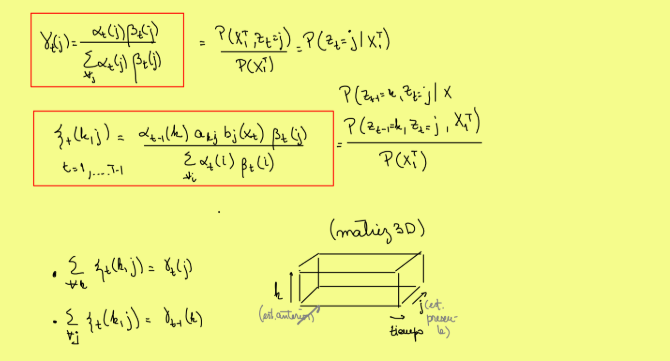

$$
\begin{align}
\log  P(x_1^{T}) &= \log \sum_\limits{j=1}^{N-1} P(z_1^{T}, z_t=j) \\
&=\log \sum_\limits{j=1}^{N-1} \alpha_t(j) \beta_t(j)  \\
&=\log \sum_\limits{j=1}^{N-1} e^{ \log [\alpha_t(j)]  + \log [\beta_t](j) ]}
\end{align}
$$

In [13]:
log_prob, log_alpha = logfw(X2, HMM[2])
log_prob, log_beta  = logbw(X2, HMM[2])

logsumexp(log_alpha + log_beta, axis=0)

array([-111.42930782, -111.42930782, -111.42930782, -111.42930782,
       -111.42930782, -111.42930782, -111.42930782, -111.42930782,
       -111.42930782])

<Figure size 800x500 with 0 Axes>

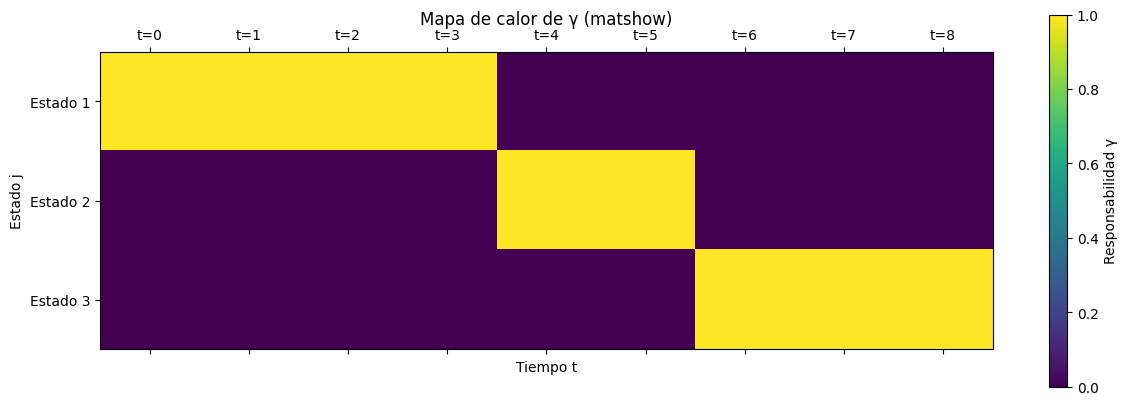

In [14]:
log_prob, log_alpha = logfw(X2, HMM[2])
log_prob, log_beta  = logbw(X2, HMM[2])
gamma_log = (log_alpha + log_beta) - logsumexp(log_alpha + log_beta, axis=0)
gamma = np.exp(gamma_log)

# Graficamos con matshow
plt.figure(figsize=(8, 5))
plt.matshow(gamma, cmap='viridis')
plt.colorbar(label='Responsabilidad γ')
plt.title('Mapa de calor de γ (matshow)', pad=20)
plt.xlabel('Tiempo t')
plt.ylabel('Estado j')

# Etiquetas personalizadas (opcional)
plt.xticks(ticks=np.arange(gamma.shape[1]), labels=[f"t={i}" for i in range(gamma.shape[1])])
plt.yticks(ticks=np.arange(gamma.shape[0]), labels=[f"Estado {j+1}" for j in range(gamma.shape[0])])

plt.show()




$$
P(x_1^T) = \sum_j P(x_1^T, z_t = j)
= \sum_j \alpha_t(j) , \beta_t(j)
\quad \text{para cualquier } t
$$

* **Responsabilidad**
$$
\gamma_t(j) = P(z_t = j \mid x_1^T)
= \frac{P(x_1^T, z_t = j)}{P(x_1^T)}
= \frac{\alpha_t(j), \beta_t(j)}{\sum_j \alpha_t(j), \beta_t(j)}
$$

* **Respoinsabilidad conjunta para dos estados contiguos**
$$
\xi_t(k,j) = P(z_{t+1} = k, z_{t} = j \mid X)
= \frac{\alpha_{t-1}(k) \ a_{kj}\  b_j(x_{t})\  \beta_{t}(j)}
{\sum_\limits{\forall j} \alpha_t(i), \beta_t(i)}
$$


$$
\begin{align}
t   &∈ \{1,2,3, ....T-1\}\\
t_α &∈ \{0,2,3, ....T-2\}\\
t_b &∈ \{1,2,3, ....T-1\}\\
t_β &∈ \{1,2,3, ....T-1\}\\
\end{align}
$$

**Tienen la misma longuitud!**

In [15]:
class Kmeans:
  def __init__(self,K,it=500):
    self.K = K
    self.it = it
    self.labels_ = None
    self.cluster_centers_ = None

  def fit(self,X):
    self.cluster_centers_ = self._inicializar(X,self.K)
    for i in range(self.it):
      self.labels_ = self._minimization(X,self.cluster_centers_)
      self.cluster_centers_ = self._expectation(X,self.labels_)
    return self

  def predict(self,X):
    return self._minimization(X,self.cluster_centers_)

  def _inicializar(self,X,num_clusters):
    idx_centroides = np.random.choice(X.shape[0], size=num_clusters, replace=False)
    return X[idx_centroides,:]

  #clasifico
  def _minimization(self,X,centroides):
    d2 = np.sum((X[:,:,np.newaxis] - centroides[:,:,np.newaxis].T)**2,axis=1)
    clasificacion = np.argmin(d2,axis=1)
    return clasificacion

  # calculo centroides
  def _expectation(self,X,clasificacion):
    c = np.unique(clasificacion).shape[0]
    centroides = np.empty((c,X.shape[1]))
    for k in range(c):
      centroides[k,:] = X[clasificacion == k,:].mean(axis=0)
    return centroides

In [16]:
class BW:
    def __init__(self, hmm, it=500):
        #self.K      = K #Acá la cantidad de cluster esta dada por el modelo o X, seria N.
        self.it     = it
        self.hmm    = hmm
        self.T      = None
        self.N      = hmm.numStates-2

    def fit(self, X, init_kmeans=False):
        self.T = X.shape[0]
        if init_kmeans: self._inicializar(X, self.N)
        for i in range(self.it):
            log_posteriors, log_xi = self._expectation(X)
            self._maximization(X, np.exp(log_posteriors), np.exp(log_xi))


    def predict_proba(self,X):
        log_prob, _ = self._expectation(X)
        return log_prob

    def predict(self,X):
        return np.argmax(self.predict_proba(X),axis=1)

    def _inicializar(self, X, num_clusters):
        kmeans = Kmeans(K=num_clusters).fit(X)
        medias = kmeans.cluster_centers_
        clasificacion_sk = kmeans.labels_
        pesos = np.empty(num_clusters)
        vars  = np.empty((num_clusters, self.medias.shape[1], self.medias.shape[1]))

        for k in range(num_clusters):
            pesos[k]= np.mean(clasificacion_sk==k)
            vars[k] = np.cov(X[clasificacion_sk==k].T)

        self.hmm.means = medias
        self.hmm.vrs = vars

    def _get_model(self, X, hmm, N, T):
        tmp = np.copy(hmm.trans)
        tmp[tmp < 1e-320] = 1e-320
        log_a = np.log(tmp)

        log_b = -np.ones((N,T))*np.log(2*np.pi)
        for k in range(N): #para todo T->:
            log_b[k,:] -= 0.5 * np.log(np.linalg.det(hmm.vrs[k]))
            x_unbiased  = X - hmm.means[k,np.newaxis]
            inv_sig     =  np.linalg.inv(hmm.vrs[k])
            log_b[k,:] -= 0.5 * np.einsum('ij,ij->i',x_unbiased @ inv_sig, x_unbiased).T
        return log_a, log_b.T

    def _expectation(self,X):
        """
        Calculo las responsabilidades:
                    α_t(j),β_t(j)
        γt(j)   =  -----------------
                    ∑_∀j αt(i),βt(i)

                    α_{t−1}(k) a_{kj} b_j(xt) β_t(j)
        ξt(k,j) =   --------------------------------
                        ∑_∀j αt(i),βt(i)

        Retorna: log_gamma, log_xi
        """
        #Queremos que el tiempo vaya primero para vectorizar.
        _, log_alpha = logfw(X, self.hmm)
        _, log_beta  = logbw(X, self.hmm)

        log_alpha, log_beta = log_alpha.T, log_beta.T                #(T, N), (T, N)
        log_a, log_b = self._get_model(X, self.hmm, self.N, self.T)  #(N, N), (T, N)


        #logSumNk = logsumexp(log_alpha + log_beta, axis=1)[:,None] print(logSumNk)     SON CTES ! x T
        logSumNk = logsumexp(log_alpha + log_beta, axis=1)[1]              #Solo calculo uno

        # log γt(j)
        log_gamma = np.zeros((self.T, self.N))
        log_gamma = (log_alpha + log_beta) - logSumNk


        #log ξt(k,j) index: (t, k,j)
        log_xi = np.zeros((self.T-1, self.N, self.N))
        log_xi = (
            log_alpha[:-1, :, None]                       # (T-1, N, 1)
            + log_a[None, 1:self.N+1, 1:self.N+1]         # (1  , N, N) / log_A.shape=(N+2,N+2)
            + np.transpose(log_b[1:, None, :], (0, 1, 2)) # (T-1, 1, N)
            + log_beta[1:, None, :]                       # (T-1, 1, N)
        )
        log_xi -= logSumNk

        return log_gamma, log_xi


    def _maximization(self, X, posteriors, xi):
        #A
        self.hmm.trans[1:self.N+1, 1:self.N+1] =  np.sum(xi, axis = 0) / np.sum(posteriors, axis = 0)
        self.hmm.trans[self.N, self.N+1]       = 1 - np.sum(self.hmm.trans[self.N,:-1])            #prob. de caer al est. final

        S = np.sum(posteriors, axis=0)
        #self.pesos = S/X.shape[0]
        #mu
        self.hmm.means= posteriors.T @ X / S[:,np.newaxis]

        #v
        aux = np.einsum('nka,nkb->nkab', X[:,np.newaxis]-self.hmm.means, X[:,np.newaxis]-self.hmm.means)
        self.hmm.vrs  = np.einsum('nkab,nk->kab', aux, posteriors) / S[:,np.newaxis,np.newaxis]


Genero set de entrenamiento.

[17  5 27]
[ 2 33  8]
[ 9  1 27]
[32  5 10]
[ 5 16 21]
[ 3 37  1]
[12  9 12]
[16 14 18]
[ 3 26  8]
[17 24 10]
[ 9 23  3]
[11 18  1]
[22 15 15]
[25 20 17]
[ 24   3 154]
[39 14  2]
[14 16 20]
[ 2 18  8]
[ 8 53 20]
[ 7 17 16]
[ 4 23 34]
[ 7  1 15]
[ 9 27 32]
[11 15 50]
[43 13 10]
[3 7 8]
[72  5 35]
[23  8 22]
[6 4 4]
[ 4 22  4]
[ 6 28 40]
[26 13  8]
[ 4  4 33]
[39  6 65]
[ 4  8 33]
[11 32 12]
[ 2 16  8]
[ 8 17 18]
[17 29 43]
[26 13  2]
[19 62  3]
[45 39  6]
[13 13 34]
[23 13 30]
[11  3 36]
[ 6 28  9]
[ 6  4 61]
[25 16 12]
[38  4 12]
[10 21 37]
[35 15  1]
[ 2 37  7]
[16 15  8]
[23 21  1]
[21 21 22]


Text(0.5, 1.0, 'HMM[4], secuencia Xtrain, Ztrain')

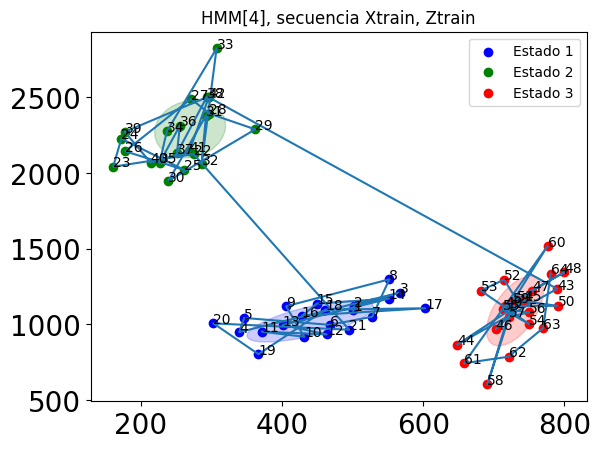

In [17]:
X_train, Z_train= genhmm(HMM[4])
min_state = 20
while not (np.bincount(Z_train)[1:-1] >= min_state).all():
 X_train, Z_train= genhmm(HMM[4])
 print(np.bincount(Z_train)[1:-1])
 #X_train = np.r_[X_train, x]
 #Z_train = np.r_[Z_train, z]



ax = plotseq2(HMM[4], Z_train, X_train, gauss=True)
ax.set_title('HMM[4], secuencia Xtrain, Ztrain')

In [18]:
#Defino los parametros de arranque
means = np.ones((3,2))*np.mean(X_train,axis=0)
vrs   = np.ones((3, 2,2))*np.cov(X_train, rowvar=False)
trans = np.array([
                    [0.0, 1.0, 0.0, 0.0, 0.0],
                    [0.0, 0.5, 0.5, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5, 0.5],
                    [0.0, 0.0, 0.0, 0.0, 1.0]
                ])

hmm_brian = hmm(means, vrs, trans)

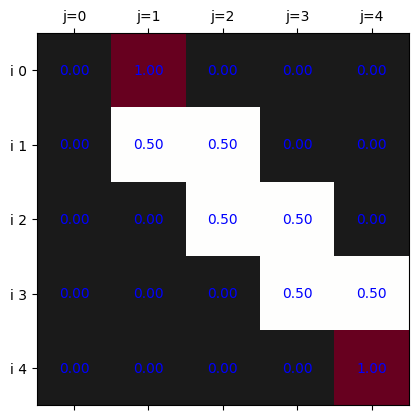

In [19]:
# Graficamos con matshow


plt.matshow(trans, cmap='RdGy_r')

plt.xticks(ticks=np.arange(trans.shape[1]), labels=[f"j={i}" for i in range(trans.shape[1])])
plt.yticks(ticks=np.arange(trans.shape[0]), labels=[f"i {j}" for j in range(trans.shape[0])])

for i, j in np.ndindex(trans.shape):
    plt.text(j, i, f"{trans[i, j]:.2f}", ha='center', va='center', color='blue')

plt.show()

In [20]:
bw_model = BW(hmm_brian, it=100)
bw_model.fit(X_train)

In [21]:
Z_pred = bw_model.predict(X_train) + 1


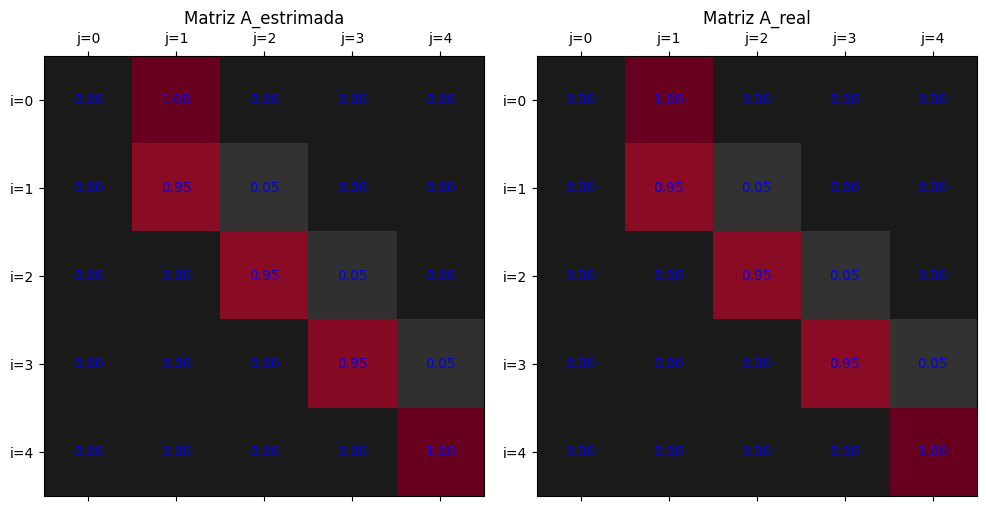

In [22]:
A_traines = bw_model.hmm.trans

µy = bw_model.hmm.means
Σ = bw_model.hmm.vrs

A_real = HMM[4].trans

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Primer gráfico: A_traines
axs[0].matshow(A_traines, cmap='RdGy_r')
axs[0].set_xticks(np.arange(A_traines.shape[1]))
axs[0].set_xticklabels([f"j={i}" for i in range(A_traines.shape[1])])
axs[0].set_yticks(np.arange(A_traines.shape[0]))
axs[0].set_yticklabels([f"i={j}" for j in range(A_traines.shape[0])])
axs[0].set_title("Matriz A_estrimada")
for i, j in np.ndindex(A_traines.shape):
    axs[0].text(j, i, f"{A_traines[i, j]:.2f}", ha='center', va='center', color='blue')

# Segundo gráfico: A_real
axs[1].matshow(A_real, cmap='RdGy_r')
axs[1].set_xticks(np.arange(A_real.shape[1]))
axs[1].set_xticklabels([f"j={i}" for i in range(A_real.shape[1])])
axs[1].set_yticks(np.arange(A_real.shape[0]))
axs[1].set_yticklabels([f"i={j}" for j in range(A_real.shape[0])])
axs[1].set_title("Matriz A_real")
for i, j in np.ndindex(A_real.shape):
    axs[1].text(j, i, f"{A_real[i, j]:.2f}", ha='center', va='center', color='blue')

plt.tight_layout()
plt.show()

In [23]:
def get_cov_ellipse(cov, centre, nstd, **kwargs):
    """
    Return a matplotlib Ellipse patch representing the covariance matrix
    cov centred at centre and scaled by the factor nstd.
    ref: https://scipython.com/book/chapter-7-matplotlib/examples/bmi-data-with-confidence-ellipses/
    """
    from matplotlib.patches import Ellipse

    # Find and sort eigenvalues and eigenvectors into descending order
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # The anti-clockwise angle to rotate our ellipse by
    vx, vy = eigvecs[:,0][0], eigvecs[:,0][1]
    theta = np.arctan2(vy, vx)

    # Width and height of ellipse to draw
    width, height = 2 * nstd * np.sqrt(eigvals)
    return Ellipse(xy=centre, width=width, height=height,
                   angle=np.degrees(theta), **kwargs)


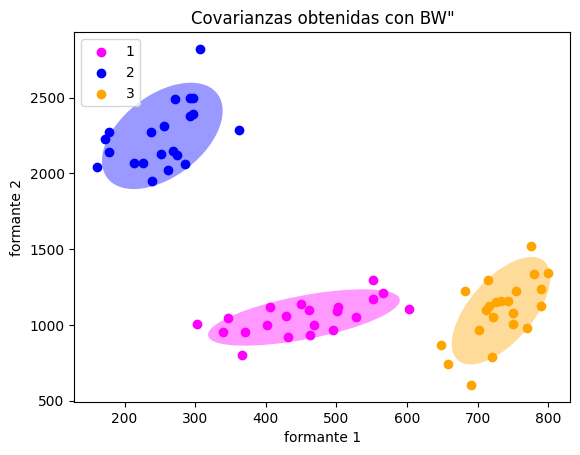

In [24]:
#vocales = {"a": None, "o": None, "u": None}
vocales = {"1": None, "2": None, "3": None}
colours = ['magenta', 'blue', 'orange']


for idx, vocal in enumerate(vocales):
    vocales[vocal] = X_train[Z_pred == (idx+1)]

# Gráfico
fig, ax = plt.subplots()
for i, (vocal, datos) in enumerate(vocales.items()):
    ax.scatter(datos[:,0], datos[:,1], color=colours[i], label = vocal)

    e = get_cov_ellipse(Σ[i], µy[i], 1.7, fc=colours[i], alpha=0.4)
    ax.add_artist(e)

ax.set_xlabel('formante 1')
ax.set_ylabel('formante 2')
plt.title('Covarianzas obtenidas con BW"')
ax.legend(loc='upper left', scatterpoints=1)
plt.show()

Ahora inicializamos uniformenente en el tiempo!

Osea, con tres clases agarramos en el tiempo T y tomamos cada T/3 para calcular una media y covarianza para cada uno asi como la prob. priori.


In [25]:
vrs.shape

(3, 2, 2)

In [26]:
#Defino los parametros de arranque
means = np.array([np.mean(x,axis=0) for x in np.array_split(X_train,3)])
vrs   = np.array([np.cov(X_train, rowvar=False) for x in np.array_split(X_train,3)])
trans = np.array([
                    [0.0, 1.0, 0.0, 0.0, 0.0],
                    [0.0, 0.5, 0.5, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5, 0.5],
                    [0.0, 0.0, 0.0, 0.0, 1.0]
                ])

hmm_brian = hmm(means, vrs, trans)

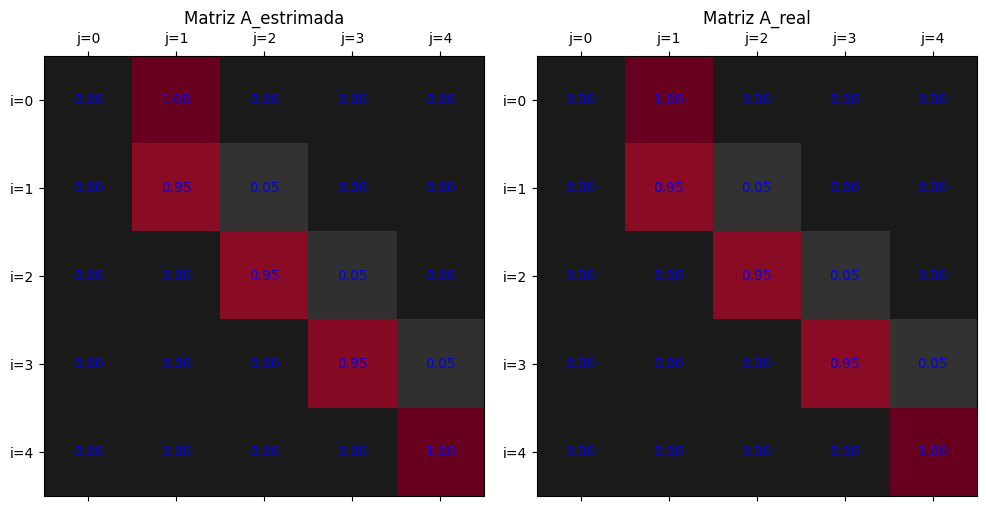

In [27]:
bw_model = BW(hmm_brian, it=100)
bw_model.fit(X_train)


A_traines = bw_model.hmm.trans
µy = bw_model.hmm.means
Σ = bw_model.hmm.vrs

A_real = HMM[4].trans

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Primer gráfico: A_traines
axs[0].matshow(A_traines, cmap='RdGy_r')
axs[0].set_xticks(np.arange(A_traines.shape[1]))
axs[0].set_xticklabels([f"j={i}" for i in range(A_traines.shape[1])])
axs[0].set_yticks(np.arange(A_traines.shape[0]))
axs[0].set_yticklabels([f"i={j}" for j in range(A_traines.shape[0])])
axs[0].set_title("Matriz A_estrimada")
for i, j in np.ndindex(A_traines.shape):
    axs[0].text(j, i, f"{A_traines[i, j]:.2f}", ha='center', va='center', color='blue')

# Segundo gráfico: A_real
axs[1].matshow(A_real, cmap='RdGy_r')
axs[1].set_xticks(np.arange(A_real.shape[1]))
axs[1].set_xticklabels([f"j={i}" for i in range(A_real.shape[1])])
axs[1].set_yticks(np.arange(A_real.shape[0]))
axs[1].set_yticklabels([f"i={j}" for j in range(A_real.shape[0])])
axs[1].set_title("Matriz A_real")
for i, j in np.ndindex(A_real.shape):
    axs[1].text(j, i, f"{A_real[i, j]:.2f}", ha='center', va='center', color='blue')

plt.tight_layout()
plt.show()

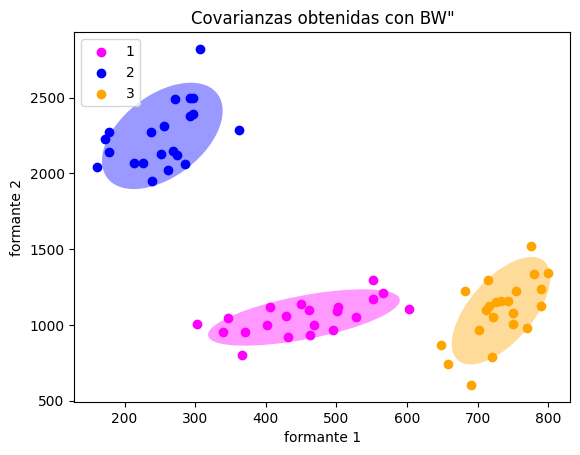

In [28]:
#vocales = {"a": None, "o": None, "u": None}
vocales = {"1": None, "2": None, "3": None}
colours = ['magenta', 'blue', 'orange']


for idx, vocal in enumerate(vocales):
    vocales[vocal] = X_train[bw_model.predict(X_train) == idx]

# Gráfico
fig, ax = plt.subplots()
for i, (vocal, datos) in enumerate(vocales.items()):
    ax.scatter(datos[:,0], datos[:,1], color=colours[i], label = vocal)

    e = get_cov_ellipse(Σ[i], µy[i], 1.7, fc=colours[i], alpha=0.4)
    ax.add_artist(e)

ax.set_xlabel('formante 1')
ax.set_ylabel('formante 2')
plt.title('Covarianzas obtenidas con BW"')
ax.legend(loc='upper left', scatterpoints=1)
plt.show()

Ahora veamos con hmm6

Text(0.5, 1.0, 'HMM[6], secuencia Xtrain, Ztrain')

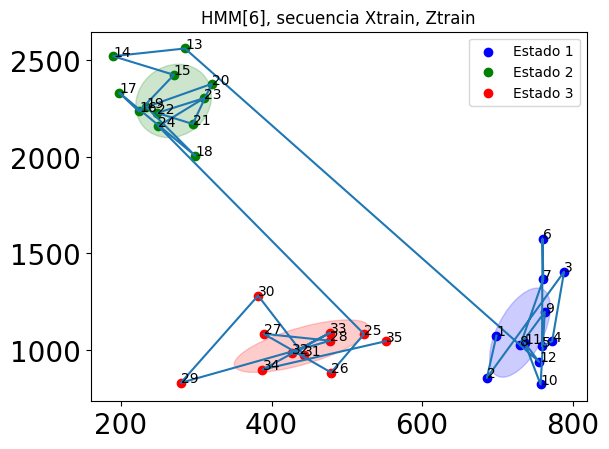

In [29]:
X_train, Z_train= genhmm(HMM[6])
min_state = 10
while not (np.bincount(Z_train)[1:-1] >= min_state).all():
 X_train, Z_train= genhmm(HMM[6])
 #print(np.bincount(Z_train)[1:-1])
 #X_train = np.r_[X_train, x]
 #Z_train = np.r_[Z_train, z]



ax = plotseq2(HMM[6], Z_train, X_train, gauss=True)
ax.set_title('HMM[6], secuencia Xtrain, Ztrain')

In [30]:
#Defino los parametros de arranque
means = np.ones((3,2))*np.mean(X_train,axis=0)
vrs   = np.ones((3, 2,2))*np.cov(X_train, rowvar=False)
trans = np.array([
                    [0.0, 1.0, 0.0, 0.0, 0.0],
                    [0.0, 0.5, 0.5, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5, 0.5],
                    [0.0, 0.0, 0.0, 0.0, 1.0]
                ])

hmm_brian = hmm(means, vrs, trans)

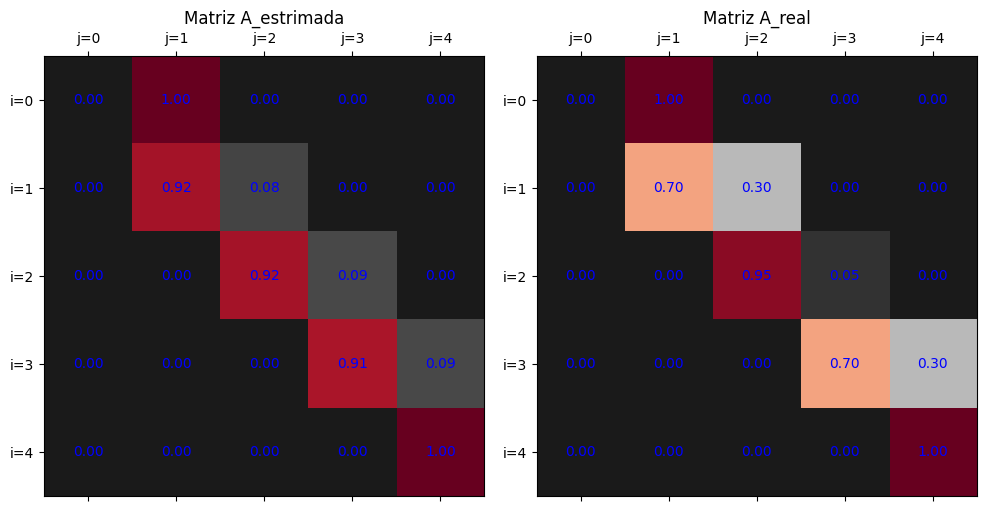

In [31]:
bw_model = BW(hmm_brian, it=100)
bw_model.fit(X_train)


A_traines = bw_model.hmm.trans
µy = bw_model.hmm.means
Σ = bw_model.hmm.vrs

A_real = HMM[6].trans

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Primer gráfico: A_traines
axs[0].matshow(A_traines, cmap='RdGy_r')
axs[0].set_xticks(np.arange(A_traines.shape[1]))
axs[0].set_xticklabels([f"j={i}" for i in range(A_traines.shape[1])])
axs[0].set_yticks(np.arange(A_traines.shape[0]))
axs[0].set_yticklabels([f"i={j}" for j in range(A_traines.shape[0])])
axs[0].set_title("Matriz A_estrimada")
for i, j in np.ndindex(A_traines.shape):
    axs[0].text(j, i, f"{A_traines[i, j]:.2f}", ha='center', va='center', color='blue')

# Segundo gráfico: A_real
axs[1].matshow(A_real, cmap='RdGy_r')
axs[1].set_xticks(np.arange(A_real.shape[1]))
axs[1].set_xticklabels([f"j={i}" for i in range(A_real.shape[1])])
axs[1].set_yticks(np.arange(A_real.shape[0]))
axs[1].set_yticklabels([f"i={j}" for j in range(A_real.shape[0])])
axs[1].set_title("Matriz A_real")
for i, j in np.ndindex(A_real.shape):
    axs[1].text(j, i, f"{A_real[i, j]:.2f}", ha='center', va='center', color='blue')

plt.tight_layout()
plt.show()

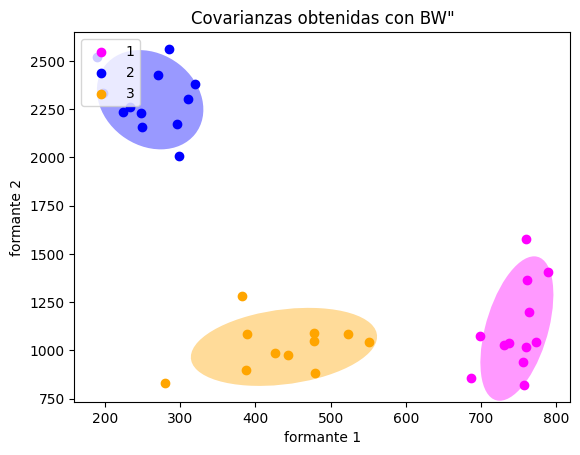

In [32]:
#vocales = {"a": None, "o": None, "u": None}
vocales = {"1": None, "2": None, "3": None}
colours = ['magenta', 'blue', 'orange']


for idx, vocal in enumerate(vocales):
    vocales[vocal] = X_train[bw_model.predict(X_train) == idx]

# Gráfico
fig, ax = plt.subplots()
for i, (vocal, datos) in enumerate(vocales.items()):
    ax.scatter(datos[:,0], datos[:,1], color=colours[i], label = vocal)

    e = get_cov_ellipse(Σ[i], µy[i], 1.7, fc=colours[i], alpha=0.4)
    ax.add_artist(e)

ax.set_xlabel('formante 1')
ax.set_ylabel('formante 2')
plt.title('Covarianzas obtenidas con BW"')
ax.legend(loc='upper left', scatterpoints=1)
plt.show()

Veamos con inicializacion uniforme

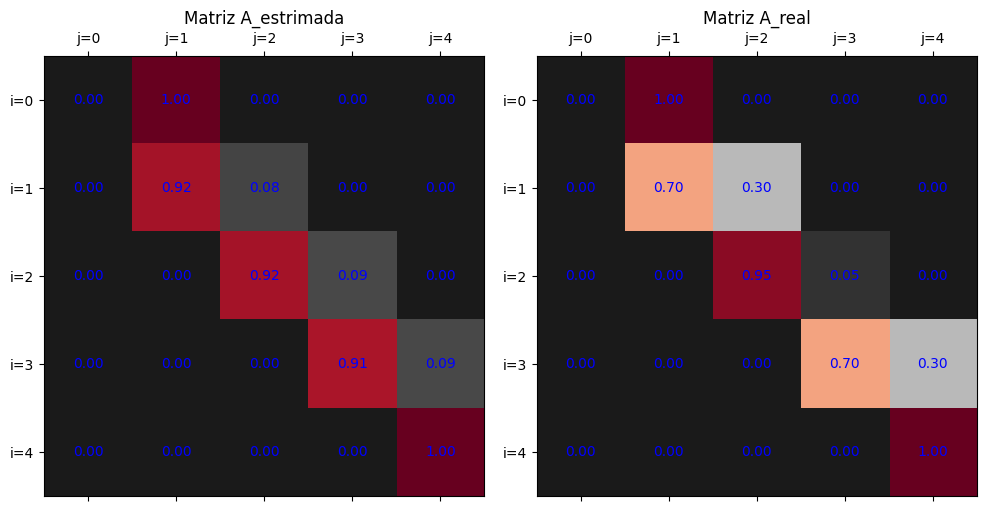

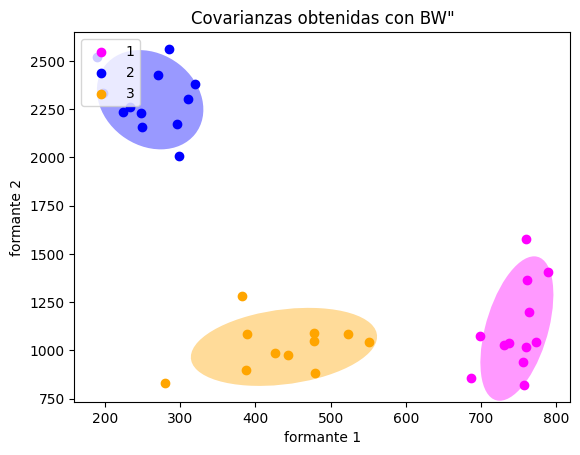

In [33]:
#Defino los parametros de arranque
means = np.array([np.mean(x,axis=0) for x in np.array_split(X_train,3)])
vrs   = np.array([np.cov(X_train, rowvar=False) for x in np.array_split(X_train,3)])
trans = np.array([
                    [0.0, 1.0, 0.0, 0.0, 0.0],
                    [0.0, 0.5, 0.5, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5, 0.5],
                    [0.0, 0.0, 0.0, 0.0, 1.0]
                ])

hmm_brian = hmm(means, vrs, trans)
#######----------------


bw_model = BW(hmm_brian, it=100)
bw_model.fit(X_train)


A_traines = bw_model.hmm.trans
µy = bw_model.hmm.means
Σ = bw_model.hmm.vrs

A_real = HMM[6].trans

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Primer gráfico: A_traines
axs[0].matshow(A_traines, cmap='RdGy_r')
axs[0].set_xticks(np.arange(A_traines.shape[1]))
axs[0].set_xticklabels([f"j={i}" for i in range(A_traines.shape[1])])
axs[0].set_yticks(np.arange(A_traines.shape[0]))
axs[0].set_yticklabels([f"i={j}" for j in range(A_traines.shape[0])])
axs[0].set_title("Matriz A_estrimada")
for i, j in np.ndindex(A_traines.shape):
    axs[0].text(j, i, f"{A_traines[i, j]:.2f}", ha='center', va='center', color='blue')

# Segundo gráfico: A_real
axs[1].matshow(A_real, cmap='RdGy_r')
axs[1].set_xticks(np.arange(A_real.shape[1]))
axs[1].set_xticklabels([f"j={i}" for i in range(A_real.shape[1])])
axs[1].set_yticks(np.arange(A_real.shape[0]))
axs[1].set_yticklabels([f"i={j}" for j in range(A_real.shape[0])])
axs[1].set_title("Matriz A_real")
for i, j in np.ndindex(A_real.shape):
    axs[1].text(j, i, f"{A_real[i, j]:.2f}", ha='center', va='center', color='blue')

plt.tight_layout()
plt.show()


#####----------

#vocales = {"a": None, "o": None, "u": None}
vocales = {"1": None, "2": None, "3": None}
colours = ['magenta', 'blue', 'orange']


for idx, vocal in enumerate(vocales):
    vocales[vocal] = X_train[bw_model.predict(X_train) == idx]

# Gráfico
fig, ax = plt.subplots()
for i, (vocal, datos) in enumerate(vocales.items()):
    ax.scatter(datos[:,0], datos[:,1], color=colours[i], label = vocal)

    e = get_cov_ellipse(Σ[i], µy[i], 1.7, fc=colours[i], alpha=0.4)
    ax.add_artist(e)

ax.set_xlabel('formante 1')
ax.set_ylabel('formante 2')
plt.title('Covarianzas obtenidas con BW"')
ax.legend(loc='upper left', scatterpoints=1)
plt.show()

In [34]:
Z_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

<Figure size 1000x800 with 0 Axes>

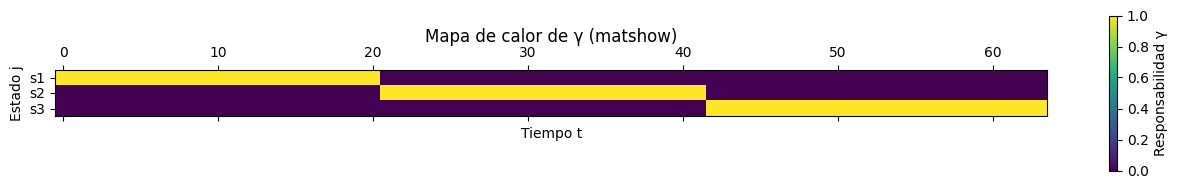

In [35]:
T = Z_pred.shape[0]

one_hot = np.zeros((3, T))
one_hot[Z_pred-1, np.arange(T)] = 1


# Graficamos con matshow
plt.figure(figsize=(10, 8))
plt.matshow(one_hot, cmap='viridis')
plt.colorbar(label='Responsabilidad γ')
plt.title('Mapa de calor de γ (matshow)', pad=20)
plt.xlabel('Tiempo t')
plt.ylabel('Estado j')

# Etiquetas personalizadas (opcional)
#plt.xticks(ticks=np.arange(one_hot.shape[1]), labels=[f"t={i}" for i in range(one_hot.shape[1])])
plt.yticks(ticks=np.arange(one_hot.shape[0]), labels=[f"s{j+1}" for j in range(one_hot.shape[0])])

plt.show()


### 3. Algoritmo de Viterbi

**a)** La función `logvit` calcula el **camino óptimo de Viterbi** para una secuencia dada y un modelo de Markov.

Encontrar el camino óptimo para cada una de las secuencias del ejercicio anterior, usando el modelo que da la **máxima verosimilitud**.



**b)** Esta función también calcula la **probabilidad de la secuencia** sobre ese camino óptimo.

Comparar esa probabilidad con:

* La probabilidad de la secuencia considerando **todos los caminos posibles**, y
* La probabilidad de la **secuencia real** (calculadas en el ejercicio anterior).



**c)** Usar la función `compseq` para **comparar** la secuencia obtenida con Viterbi contra la **secuencia verdadera**.


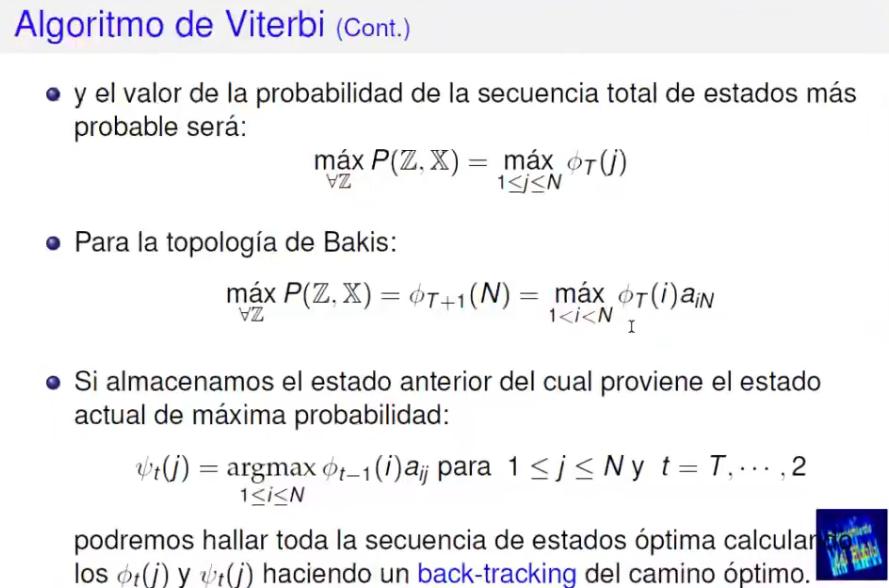

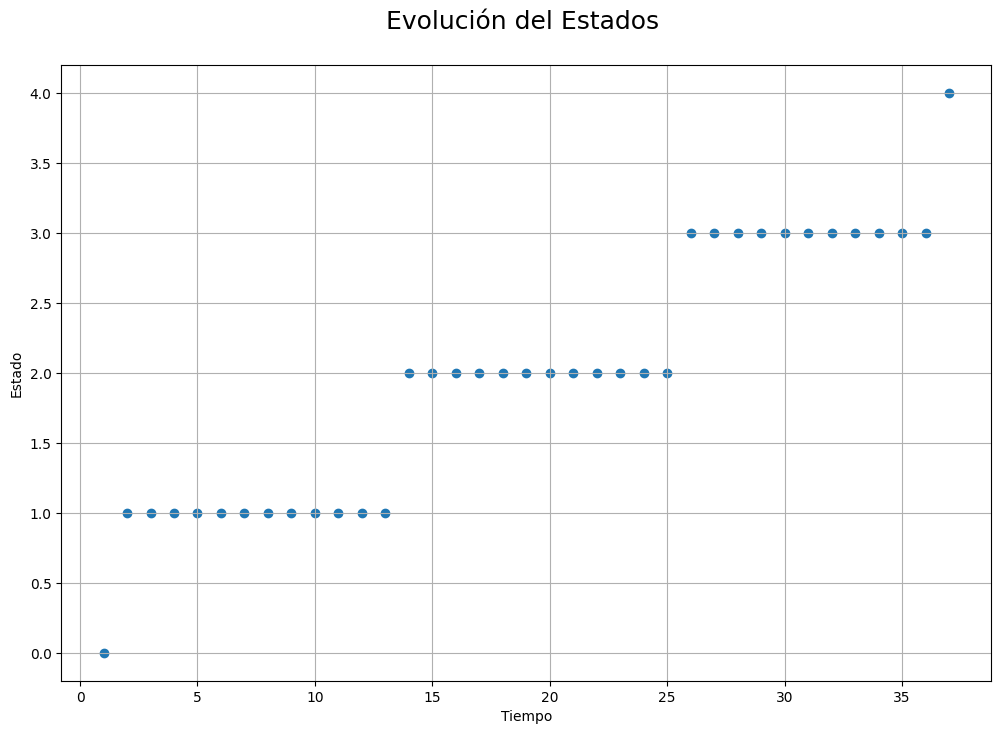

In [36]:

costOPt, log_pi, seq = logvit(X_train,bw_model.hmm)


#Grafico el likelihood
fig = plt.figure(figsize=(12,8))
fig.tight_layout()
plt.subplot(1,1,1)


plt.scatter(np.arange(1,len(seq)+1,1),seq)
plt.xlabel("Tiempo")
plt.ylabel("Estado")
plt.grid()
plt.title("Evolución del Estados \n",fontsize=18)
plt.show()



### 4. Detección de Modelos Conectados

**a)** Construir un modelo oculto de Markov que pueda generar indistintamente `hmm4` o `hmm6`, con igual probabilidad de comenzar en uno o en otro, y de terminar después de generar cualquiera de ellos.

Este nuevo modelo debe tener las mismas **medias y varianzas** que los modelos del punto 1a, pero se debe **modificar la matriz de transición** para cumplir lo solicitado.

Con este modelo, generar una secuencia de observaciones y determinar la secuencia de estados más probable usando `logvit.m`.

Comparar ambas secuencias y determinar qué **secuencia de modelos** se produjo durante la emisión.



**b)** Repetir el reconocimiento de la secuencia de estados con la secuencia generada en el punto 1a.
